In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

BASE = os.getcwd() + '\\'

def load(f):
    for enc in ['utf-8', 'latin-1']:
        try:
            return pd.read_csv(BASE + f, sep=None, engine='python', encoding=enc)
        except:
            continue

# MUR
df_imm   = load('MURimmatricolatixclasse.csv')
df_1anno = load('MURiscritti1annoxateneo.csv')
df_isc   = load('MURiscrittixclasse.csv')
df_lau   = load('MUR_laureatixclasse.csv')
df_corso = load('MURiscrittixcorsodistudi.csv')
df_alma_reg = load('almalaurea_2024_clean.csv')
df_alma_reg.columns = df_alma_reg.columns.str.strip().str.lstrip('\ufeff')

# Filtra L-2
imm_l2   = df_imm[df_imm['ClasseNUMERO'].astype(str).str.strip() == 'L-2'].copy()
anno1_l2 = df_1anno[df_1anno['ClasseNUMERO'].astype(str).str.strip() == 'L-2'].copy()
isc_l2   = df_isc[df_isc['ClasseNUMERO'].astype(str).str.strip() == 'L-2'].copy()
lau_l2   = df_lau[df_lau['ClasseNUMERO'].astype(str).str.strip() == 'L-2'].copy()
corso_l2 = df_corso[df_corso['ClasseNUMERO'].astype(str).str.strip() == 'L-2'].copy()

# Macro area
MACRO = {
    'Torino': 'Nord', 'Piemonte Orientale': 'Nord', 'Milano': 'Nord',
    'Milano Bicocca': 'Nord', 'Milano Cattolica': 'Nord', 'Milano San Raffaele': 'Nord',
    'Vita-Salute': 'Nord', 'Pavia': 'Nord', 'Brescia': 'Nord', 'Bergamo': 'Nord',
    'Insubria': 'Nord', 'Trento': 'Nord', 'Bolzano': 'Nord',
    'Padova': 'Nord', 'Venezia': 'Nord', 'Verona': 'Nord',
    'Trieste': 'Nord', 'Udine': 'Nord', 'Genova': 'Nord',
    'Bologna': 'Nord', 'Ferrara': 'Nord', 'Modena': 'Nord',
    'Parma': 'Nord', 'Reggio Emilia': 'Nord',
    'Firenze': 'Centro', 'Pisa': 'Centro', 'Siena': 'Centro',
    'Perugia': 'Centro', 'Camerino': 'Centro', 'Urbino': 'Centro',
    'Ancona': 'Centro', 'Macerata': 'Centro', 'Politecnica delle Marche': 'Centro',
    'Sapienza': 'Centro', 'Tor Vergata': 'Centro', 'Roma Tre': 'Centro',
    'Tuscia': 'Centro', 'Lumsa': 'Centro', 'Unicampus': 'Centro',
    'Campus Bio': 'Centro', 'Roma': 'Centro',
    "L'Aquila": 'Centro', 'Chieti': 'Centro', 'Teramo': 'Centro',
    'Napoli': 'Sud', 'Salerno': 'Sud', 'Sannio': 'Sud',
    'Bari': 'Sud', 'Lecce': 'Sud', 'Foggia': 'Sud', 'LUM': 'Sud',
    'Salento': 'Sud', 'Basilicata': 'Sud', 'Calabria': 'Sud',
    'Catanzaro': 'Sud', 'Magna Graecia': 'Sud', 'Molise': 'Sud',
    'Palermo': 'Isole', 'Catania': 'Isole', 'Messina': 'Isole',
    'Enna': 'Isole', 'Cagliari': 'Isole', 'Sassari': 'Isole',
}

def get_macro(nome):
    for key, area in MACRO.items():
        if key.lower() in str(nome).lower():
            return area
    return 'Non classificato'

anno1_l2['macro'] = anno1_l2['AteneoNOME'].apply(get_macro)
corso_l2['macro'] = corso_l2['AteneoNOME'].apply(get_macro)

# Parser AlmaLaurea
def parse_almalaurea_csv(filepath):
    data = {}
    with open(filepath, 'r', encoding='latin-1') as f:
        for line in f:
            line = line.strip().strip('"')
            parts = line.split(';')
            if len(parts) >= 2:
                chiave = parts[0].strip().strip('"')
                valore = parts[1].strip().strip('"')
                if chiave and valore:
                    try:
                        data[chiave] = float(valore.replace('.', '').replace(',', '.'))
                    except:
                        data[chiave] = valore
    return data

anni = [2020, 2021, 2022, 2023, 2024]
profili     = {a: parse_almalaurea_csv(f'datialmalaureaPROFILO{a}.csv') for a in anni}
occupazioni = {a: parse_almalaurea_csv(f'datialmalaureaOCCUPAZIONE{a}.csv') for a in anni}

CHIAVE_ERASMUS = 'Hanno svolto periodi di studio all\xe2\x80\x99estero durante il corso di studio (%)'

alma_profilo = pd.DataFrame({
    'anno': anni,
    'n_laureati':                  [profili[a].get('Numero di laureati') for a in anni],
    'pct_donne':                   [profili[a].get('Donne') for a in anni],
    'eta_media_laurea':            [profili[a].get("Eta' alla laurea (medie, in anni)") for a in anni],
    'voto_medio_laurea':           [profili[a].get('Voto di laurea (medie, in 110-mi)') for a in anni],
    'voto_diploma':                [profili[a].get('Voto di diploma (medie, in 100-mi)') for a in anni],
    'pct_liceo_scientifico':       [profili[a].get('Liceo scientifico') for a in anni],
    'pct_tirocinio':               [profili[a].get('Hanno svolto tirocini formativi curriculari o lavoro riconosciuti dal corso di studio (%)') for a in anni],
    'pct_erasmus':                 [profili[a].get(CHIAVE_ERASMUS) for a in anni],
    'pct_magistrale':              [profili[a].get('Laurea magistrale biennale') for a in anni],
    'pct_stesso_ateneo_magistrale':[profili[a].get('Stesso Ateneo della laurea di primo livello') for a in anni],
    'pct_magistrale_nord':         [profili[a].get('Altro Ateneo del Nord') for a in anni],
    'pct_magistrale_centro':       [profili[a].get('Altro Ateneo del Centro') for a in anni],
    'pct_soddisfatti':             [round((profili[a].get('Decisamente s\xc3\xac', 0) or 0) + (profili[a].get('Pi\xc3\xb9 s\xc3\xac che no', 0) or 0), 1) for a in anni],
    'pct_riiscrizione':            [profili[a].get('S\xc3\xac, allo stesso corso dell\'Ateneo') for a in anni],
    'pct_inglese_b2':              [profili[a].get('Inglese scritto') for a in anni],
    'pct_disponibile_nord':        [profili[a].get('Italia settentrionale') for a in anni],
    'pct_disponibile_centro':      [profili[a].get('Italia centrale') for a in anni],
})

alma_occup = pd.DataFrame({
    'anno': anni,
    'retribuzione_media':      [occupazioni[a].get('Totale') for a in anni],
    'retribuzione_uomini':     [occupazioni[a].get('Uomini') for a in anni],
    'retribuzione_donne':      [occupazioni[a].get('Donne') for a in anni],
    'tasso_occupazione':       [round((occupazioni[a].get('Lavorano e non sono iscritti ad una laurea di secondo livello', 0) or 0) + (occupazioni[a].get('Lavorano e sono iscritti ad una laurea di secondo livello', 0) or 0), 1) for a in anni],
    'tasso_disoccupazione':    [occupazioni[a].get('Tasso di disoccupazione') for a in anni],
    'pct_tempo_indeterminato': [occupazioni[a].get('Tempo indeterminato') for a in anni],
    'pct_tempo_determinato':   [occupazioni[a].get('Tempo determinato') for a in anni],
    'pct_contratti_formativi': [occupazioni[a].get('Contratti formativi') for a in anni],
    'pct_part_time':           [occupazioni[a].get('Diffusione del part-time (%)') for a in anni],
    'pct_laurea_efficace':     [occupazioni[a].get('Molto efficace/Efficace') for a in anni],
    'soddisfazione_lavoro':    [occupazioni[a].get('Soddisfazione per il lavoro svolto (medie, scala 1-10)') for a in anni],
    'pct_lavora_nordovest':    [occupazioni[a].get('Nord-Ovest') for a in anni],
    'pct_lavora_nordest':      [occupazioni[a].get('Nord-Est') for a in anni],
    'pct_lavora_centro':       [occupazioni[a].get('Centro') for a in anni],
    'pct_lavora_sud':          [occupazioni[a].get('Sud') for a in anni],
    'pct_lavora_estero':       [occupazioni[a].get('Estero') for a in anni],
    'pct_settore_pubblico':    [occupazioni[a].get('Pubblico') for a in anni],
    'pct_settore_privato':     [occupazioni[a].get('Privato') for a in anni],
    'pct_chimica_energia':     [occupazioni[a].get('Chimica/Energia') for a in anni],
    'mesi_primo_lavoro':       [occupazioni[a].get('Tempo dalla laurea al reperimento del primo lavoro') for a in anni],
})

# Laureati
lau_naz = lau_l2.groupby('AnnoS')['Lau'].sum().reset_index()
lau_naz['AnnoS'] = lau_naz['AnnoS'].astype(int)
lau_naz = lau_naz[lau_naz['AnnoS'] >= 2010].reset_index(drop=True)

# Immatricolati
imm_naz = imm_l2.groupby('AnnoA')['Imm'].sum().reset_index()
imm_naz = imm_naz[imm_naz['AnnoA'].str[:4].astype(int) >= 2010].copy()
imm_naz['anno_short'] = imm_naz['AnnoA'].str[:4] + '/' + imm_naz['AnnoA'].str[7:9]
imm_naz['delta'] = imm_naz['Imm'].pct_change() * 100

# Colori macro
COLORI_MACRO = {
    'Nord'  : '#1B3A6B',
    'Centro': '#E07B39',
    'Sud'   : '#2E8B57',
    'Isole' : '#A8C4E0',
}

# GeoJSON
GEOJSON_URL = "https://raw.githubusercontent.com/openpolis/geojson-italy/master/geojson/limits_IT_regions.geojson"
GRIGIO_SCURO = ["Valle d'Aosta/Vallée d'Aoste", 'Molise']

# Regione per mappa
ATENEO_TO_REGIONE = {
    'Torino': 'Piemonte', 'Piemonte Orientale': 'Piemonte',
    'Milano': 'Lombardia', 'Milano Bicocca': 'Lombardia',
    'Milano Cattolica': 'Lombardia', 'Milano San Raffaele': 'Lombardia',
    'Vita-Salute': 'Lombardia', 'Pavia': 'Lombardia',
    'Brescia': 'Lombardia', 'Insubria': 'Lombardia',
    'Trento': 'Trentino-Alto Adige/Südtirol',
    'Padova': 'Veneto', 'Venezia': 'Veneto', 'Verona': 'Veneto',
    'Trieste': 'Friuli-Venezia Giulia', 'Udine': 'Friuli-Venezia Giulia',
    'Genova': 'Liguria',
    'Bologna': 'Emilia-Romagna', 'Ferrara': 'Emilia-Romagna',
    'Modena': 'Emilia-Romagna', 'Parma': 'Emilia-Romagna',
    'Firenze': 'Toscana', 'Pisa': 'Toscana', 'Siena': 'Toscana',
    'Perugia': 'Umbria',
    'Camerino': 'Marche', 'Urbino': 'Marche', 'Ancona': 'Marche',
    'Sapienza': 'Lazio', 'Tor Vergata': 'Lazio', 'Roma Tre': 'Lazio',
    'Tuscia': 'Lazio', 'Roma': 'Lazio', 'Unicampus': 'Lazio',
    'Campus Bio': 'Lazio',
    "L'Aquila": 'Abruzzo', 'Chieti': 'Abruzzo', 'Teramo': 'Abruzzo',
    'Napoli': 'Campania', 'Salerno': 'Campania', 'Sannio': 'Campania',
    'Bari': 'Puglia', 'Lecce': 'Puglia', 'Foggia': 'Puglia',
    'Salento': 'Puglia',
    'Basilicata': 'Basilicata',
    'Calabria': 'Calabria', 'Catanzaro': 'Calabria', 'Magna Graecia': 'Calabria',
    'Palermo': 'Sicilia', 'Catania': 'Sicilia', 'Messina': 'Sicilia',
    'Cagliari': 'Sardegna', 'Sassari': 'Sardegna',
}

def get_regione(nome):
    for key, reg in ATENEO_TO_REGIONE.items():
        if key.lower() in str(nome).lower():
            return reg
    return None

anno1_l2['regione'] = anno1_l2['AteneoNOME'].apply(get_regione)

print('✅ Setup completato — tutti i dataset pronti')

✅ Setup completato — tutti i dataset pronti


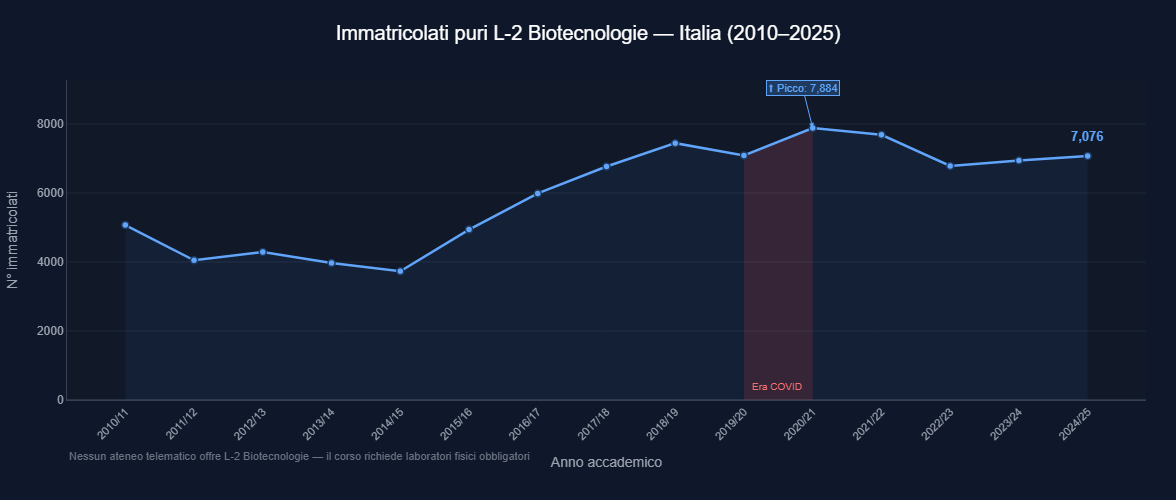

In [2]:
# ── G1 — Immatricolati puri L-2 Biotecnologie — Italia (2010–2025) ────────

imm_naz = imm_l2.groupby('AnnoA')['Imm'].sum().reset_index()
imm_naz = imm_naz[imm_naz['AnnoA'].str[:4].astype(int) >= 2010].copy()
imm_naz['anno_short'] = imm_naz['AnnoA'].str[:4] + '/' + imm_naz['AnnoA'].str[7:9]
imm_naz['delta'] = imm_naz['Imm'].pct_change() * 100
imm_naz = imm_naz.reset_index(drop=True)

y_2019 = imm_naz[imm_naz['anno_short'] == '2019/20']['Imm'].values[0]
y_2020 = imm_naz[imm_naz['anno_short'] == '2020/21']['Imm'].values[0]

fig1 = go.Figure()

# Area blu sotto tutta la linea
fig1.add_trace(go.Scatter(
    x=imm_naz['anno_short'], y=imm_naz['Imm'],
    mode='none', fill='tozeroy',
    fillcolor='rgba(59,130,246,0.08)',
    showlegend=False, hoverinfo='skip'
))

# Banda rossa COVID solo sotto i punti
fig1.add_trace(go.Scatter(
    x=['2019/20', '2020/21', '2020/21', '2019/20'],
    y=[y_2019, y_2020, 0, 0],
    fill='toself',
    fillcolor='rgba(239,68,68,0.15)',
    line=dict(color='rgba(0,0,0,0)'),
    showlegend=False, hoverinfo='skip'
))

# Linea principale
fig1.add_trace(go.Scatter(
    x=imm_naz['anno_short'], y=imm_naz['Imm'],
    mode='lines+markers',
    line=dict(color='#60A5FA', width=2.5),
    marker=dict(size=7, color='#60A5FA',
                line=dict(color='#1E3A5F', width=1.5)),
    customdata=imm_naz[['delta']].round(1),
    hovertemplate=(
        '<b>%{x}</b><br>'
        'Immatricolati: <b>%{y:,}</b><br>'
        'Variazione: %{customdata[0]:+.1f}%'
        '<extra></extra>'
    ),
    showlegend=False
))

# Annotazione picco
idx_max = imm_naz['Imm'].idxmax()
fig1.add_annotation(
    x=imm_naz.loc[idx_max, 'anno_short'],
    y=imm_naz.loc[idx_max, 'Imm'],
    text=f"⬆ Picco: {imm_naz.loc[idx_max, 'Imm']:,}",
    showarrow=True, arrowhead=2,
    arrowcolor='#60A5FA',
    font=dict(size=11, color='#60A5FA'),
    bgcolor='#1E3A5F',
    bordercolor='#60A5FA', borderwidth=1,
    ay=-40
)

# Annotazione ultimo anno
ultimo = imm_naz.iloc[-1]
fig1.add_annotation(
    x=ultimo['anno_short'], y=ultimo['Imm'],
    text=f"<b>{int(ultimo['Imm']):,}</b>",
    showarrow=False,
    font=dict(size=13, color='#60A5FA'),
    yshift=20
)

# Label Era COVID
fig1.add_annotation(
    x='2019/20', y=400,
    text='Era COVID',
    showarrow=False,
    font=dict(size=10, color='#F87171'),
    xanchor='left', xshift=6
)

# Nota telematici
fig1.add_annotation(
    x=0.0, y=-0.20,
    xref='paper', yref='paper',
    text='Nessun ateneo telematico offre L-2 Biotecnologie — il corso richiede laboratori fisici obbligatori',
    showarrow=False,
    font=dict(size=11, color='#6B7280'),
    align='left'
)

fig1.update_layout(
    title=dict(
        text='Immatricolati puri L-2 Biotecnologie — Italia (2010–2025)',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Anno accademico', font=dict(color='#9CA3AF')),
        tickangle=-45,
        showgrid=False,
        tickfont=dict(size=11, color='#9CA3AF'),
        linecolor='#374151',
    ),
    yaxis=dict(
        title=dict(text='N° immatricolati', font=dict(color='#9CA3AF')),
        gridcolor='#1F2937',
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
        rangemode='tozero'
    ),
    template='plotly_dark',
    height=500,
    margin=dict(t=80, b=100, l=60, r=30),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
)

fig1.show()

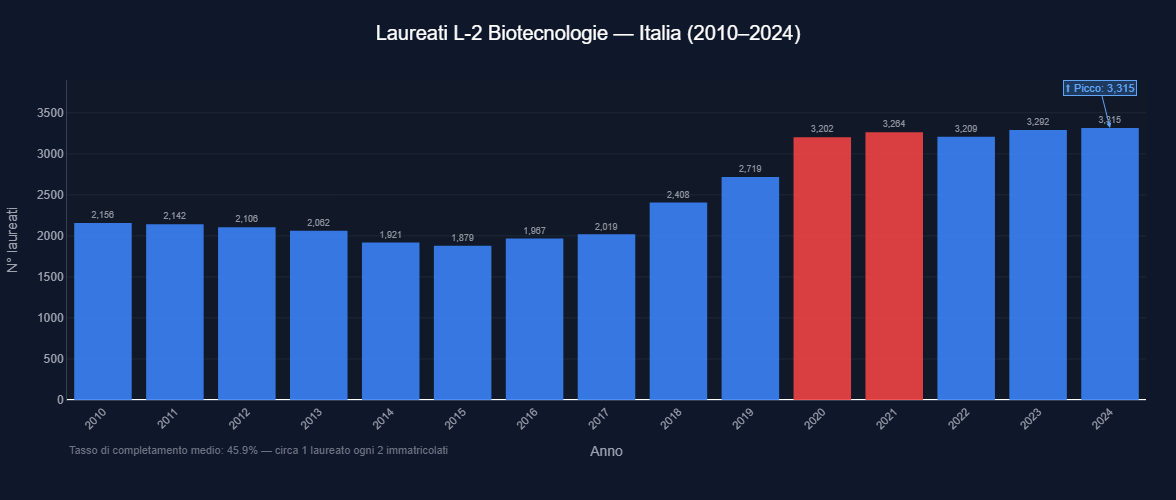

In [3]:
# ── G2 — Laureati L-2 Biotecnologie — Italia (2010–2024) ─────────────────

lau_naz = lau_l2.groupby('AnnoS')['Lau'].sum().reset_index()
lau_naz['AnnoS'] = lau_naz['AnnoS'].astype(int)
lau_naz = lau_naz[lau_naz['AnnoS'] >= 2010].reset_index(drop=True)
lau_naz['COVID'] = lau_naz['AnnoS'].isin([2020, 2021])

fig2 = px.bar(
    lau_naz,
    x='AnnoS',
    y='Lau',
    color='COVID',
    color_discrete_map={True: '#EF4444', False: '#3B82F6'},
    labels={'Lau': 'N° Laureati', 'AnnoS': 'Anno'},
    text='Lau'
)

fig2.update_traces(
    texttemplate='%{text:,}',
    textposition='outside',
    textfont=dict(size=9, color='#9CA3AF'),
    marker_line_width=0,
    opacity=0.9
)

# Annotazione picco
idx_max = lau_naz['Lau'].idxmax()
fig2.add_annotation(
    x=lau_naz.loc[idx_max, 'AnnoS'],
    y=lau_naz.loc[idx_max, 'Lau'],
    text=f"⬆ Picco: {lau_naz.loc[idx_max, 'Lau']:,}",
    showarrow=True, arrowhead=2,
    arrowcolor='#60A5FA',
    font=dict(size=11, color='#60A5FA'),
    bgcolor='#1E3A5F',
    bordercolor='#60A5FA', borderwidth=1,
    ay=-40
)

# Nota tasso completamento
fig2.add_annotation(
    x=0.0, y=-0.18,
    xref='paper', yref='paper',
    text='Tasso di completamento medio: 45.9% — circa 1 laureato ogni 2 immatricolati',
    showarrow=False,
    font=dict(size=11, color='#6B7280'),
    align='left'
)

fig2.update_layout(
    title=dict(
        text='Laureati L-2 Biotecnologie — Italia (2010–2024)',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Anno', font=dict(color='#9CA3AF')),
        tickangle=-45,
        showgrid=False,
        tickfont=dict(size=11, color='#9CA3AF'),
        tickmode='linear',
        dtick=1,
        linecolor='#374151',
    ),
    yaxis=dict(
        title=dict(text='N° laureati', font=dict(color='#9CA3AF')),
        gridcolor='#1F2937',
        tickfont=dict(color='#9CA3AF'),
        rangemode='tozero',
        linecolor='#374151',
    ),
    showlegend=False,
    height=500,
    margin=dict(t=80, b=100, l=60, r=30),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
)

fig2.show()

In [5]:
anni_disp = alma_profilo['anno'].tolist()
anni_ref = [2020, 2021, 2022, 2023]

indicatori = [
    ('pct_soddisfatti',  'Soddisfatti del corso', '#3B82F6'),
    ('pct_riiscrizione', 'Si reiscriverebbero',   '#34D399'),
    ('pct_magistrale',   'Prosegue magistrale',   '#818CF8'),
]

val_2024 = {col: float(alma_profilo[alma_profilo['anno']==2024][col].values[0]) for col, _, _ in indicatori}

fig5 = go.Figure()

for anno_ref in anni_ref:
    visible = (anno_ref == 2020)
    for col_idx, (col, titolo, colore) in enumerate(indicatori):
        val_ref = float(alma_profilo[alma_profilo['anno']==anno_ref][col].values[0])

        fig5.add_trace(go.Indicator(
            mode='gauge+number+delta',
            value=val_2024[col],
            delta={
                'reference': val_ref,
                'suffix': '%',
                'relative': False,
                'increasing': {'color': '#34D399'},
                'decreasing': {'color': '#F87171'},
            },
            number={'suffix': '%', 'font': {'size': 40, 'color': colore}},
            title={'text': f"<b style='color:#D1D5DB'>{titolo}</b><br><span style='font-size:11px;color:#6B7280'>2024 vs {anno_ref}</span>"},
            gauge={
                'axis': {'range': [0, 100], 'ticksuffix': '%',
                         'tickfont': {'color': '#6B7280'}, 'tickcolor': '#374151'},
                'bar': {'color': colore, 'thickness': 0.25},
                'bgcolor': '#1F2937',
                'borderwidth': 0,
                'steps': [
                    {'range': [0,  50],  'color': '#1F2937'},
                    {'range': [50, 75],  'color': '#243547'},
                    {'range': [75, 100], 'color': '#1E3A5F'},
                ],
                'threshold': {
                    'line': {'color': '#F59E0B', 'width': 3},
                    'thickness': 0.75,
                    'value': val_ref
                }
            },
            domain={
                'x': [col_idx * 0.34, col_idx * 0.34 + 0.30],
                'y': [0, 1]
            },
            visible=visible,
        ))

# Bottoni anno riferimento
n_per_anno = len(indicatori)
buttons = []
for i, anno_ref in enumerate(anni_ref):
    vis = []
    for j in range(len(anni_ref)):
        vis += [j == i] * n_per_anno
    buttons.append(dict(
        label=f'vs {anno_ref}',
        method='update',
        args=[
            {'visible': vis},
            {'title': dict(
                text=f'Profilo laureati L-2 — 2024 vs {anno_ref}',
                font=dict(size=20, color='white', family='Arial'),
                x=0.5, xanchor='center'
            )}
        ]
    ))

fig5.update_layout(
    title=dict(
        text='Profilo laureati L-2 Biotecnologie — 2024 vs 2020',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.5, xanchor='center',
        y=1.15, yanchor='top',
        buttons=buttons,
        bgcolor='#1F2937',
        bordercolor='#3B82F6',
        borderwidth=1,
        font=dict(size=12, family='Arial', color='white'),
        active=0,
        pad=dict(r=6, l=6, t=6, b=6),
    )],
    height=420,
    margin=dict(t=100, b=60, l=30, r=30),
    font=dict(family='Arial', size=12),
    paper_bgcolor='#0F172A',
    annotations=[
        dict(
            x=0.5, y=-0.12,
            xref='paper', yref='paper',
            text='La linea arancione indica il valore dell\'anno di riferimento selezionato',
            showarrow=False,
            font=dict(size=11, color='#6B7280'),
            align='center'
        )
    ]
)

fig5.show()

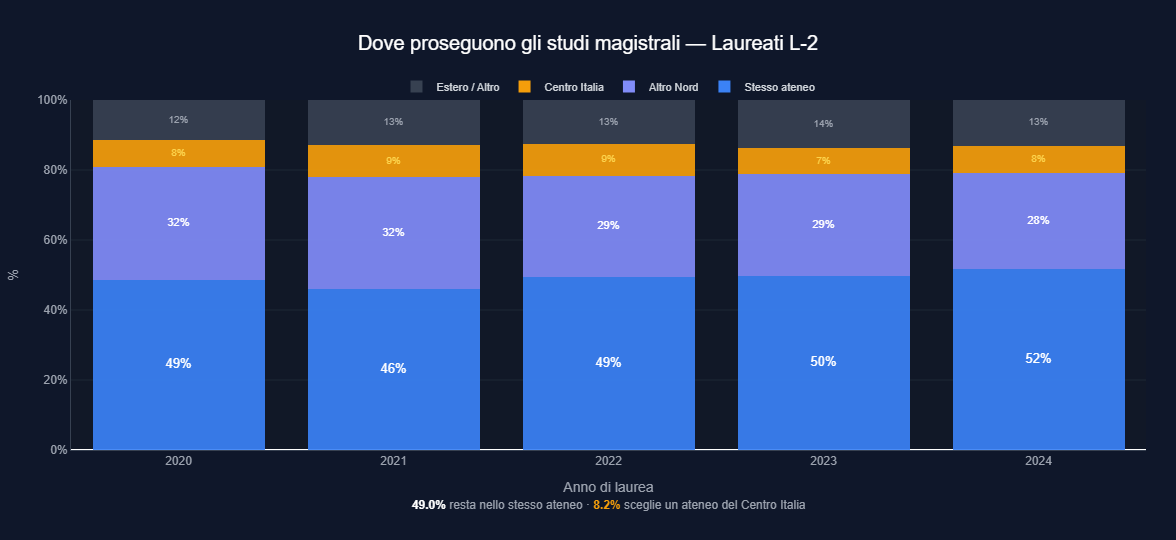

In [6]:
# ── G6 — Dove proseguono gli studi magistrali — Laureati L-2 ─────────────

g6 = alma_profilo[['anno','pct_stesso_ateneo_magistrale','pct_magistrale_nord','pct_magistrale_centro']].copy()
g6['anno'] = g6['anno'].astype(str)
g6['pct_altro'] = 100 - g6['pct_stesso_ateneo_magistrale'] - g6['pct_magistrale_nord'] - g6['pct_magistrale_centro']

DEST = {
    'pct_stesso_ateneo_magistrale': ('Stesso ateneo',  '#3B82F6'),
    'pct_magistrale_nord':          ('Altro Nord',     '#818CF8'),
    'pct_magistrale_centro':        ('Centro Italia',  '#F59E0B'),
    'pct_altro':                    ('Estero / Altro', '#374151'),
}

fig6 = go.Figure()

# Barre stacked
for col, (label, color) in DEST.items():
    fig6.add_trace(go.Bar(
        x=g6['anno'],
        y=g6[col],
        name=label,
        marker=dict(color=color, line=dict(width=0), opacity=0.92),
        hovertemplate=f'<b>{label}</b><br>Anno %{{x}}<br><b>%{{y:.1f}}%</b><extra></extra>'
    ))

# Label dentro ogni barra
for col, (label, color) in DEST.items():
    if col == 'pct_stesso_ateneo_magistrale':
        y_pos = g6[col] / 2
        font_size = 13
        font_color = 'white'
    elif col == 'pct_magistrale_nord':
        y_pos = g6['pct_stesso_ateneo_magistrale'] + g6[col] / 2
        font_size = 11
        font_color = 'white'
    elif col == 'pct_magistrale_centro':
        y_pos = g6['pct_stesso_ateneo_magistrale'] + g6['pct_magistrale_nord'] + g6[col] / 2
        font_size = 10
        font_color = '#FCD34D'
    else:
        y_pos = g6['pct_stesso_ateneo_magistrale'] + g6['pct_magistrale_nord'] + g6['pct_magistrale_centro'] + g6[col] / 2
        font_size = 10
        font_color = '#9CA3AF'

    testo = [f"{v:.0f}%" if v > 3 else "" for v in g6[col]]

    fig6.add_trace(go.Scatter(
        x=g6['anno'],
        y=y_pos,
        mode='text',
        text=testo,
        textfont=dict(size=font_size, color=font_color, family='Arial'),
        showlegend=False,
        hoverinfo='skip'
    ))

media_stesso = g6['pct_stesso_ateneo_magistrale'].mean()
media_centro = g6['pct_magistrale_centro'].mean()

fig6.update_layout(
    barmode='stack',
    title=dict(
        text='Dove proseguono gli studi magistrali — Laureati L-2',
        x=0.5, xanchor='center',
        font=dict(size=20, color='white', family='Arial')
    ),
    xaxis=dict(
        title=dict(text='Anno di laurea', font=dict(color='#9CA3AF')),
        showgrid=False,
        tickfont=dict(size=12, color='#9CA3AF'),
        linecolor='#374151',
    ),
    yaxis=dict(
        title=dict(text='%', font=dict(color='#9CA3AF')),
        range=[0, 100],
        ticksuffix='%',
        gridcolor='#1F2937',
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
    ),
    legend=dict(
        orientation='h',
        y=1.08, x=0.5, xanchor='center',
        bgcolor='rgba(0,0,0,0)',
        font=dict(color='#D1D5DB', size=11)
    ),
    height=540,
    margin=dict(t=100, b=90, l=60, r=30),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
    annotations=[
        dict(
            x=0.5, y=-0.18,
            xref='paper', yref='paper',
            text=f"<b style='color:white'>{media_stesso:.1f}%</b>"
                 f"<span style='color:#9CA3AF'> resta nello stesso ateneo · </span>"
                 f"<b style='color:#F59E0B'>{media_centro:.1f}%</b>"
                 f"<span style='color:#9CA3AF'> sceglie un ateneo del Centro Italia</span>",
            showarrow=False,
            font=dict(size=12, family='Arial'),
            align='center'
        )
    ]
)

fig6.show()

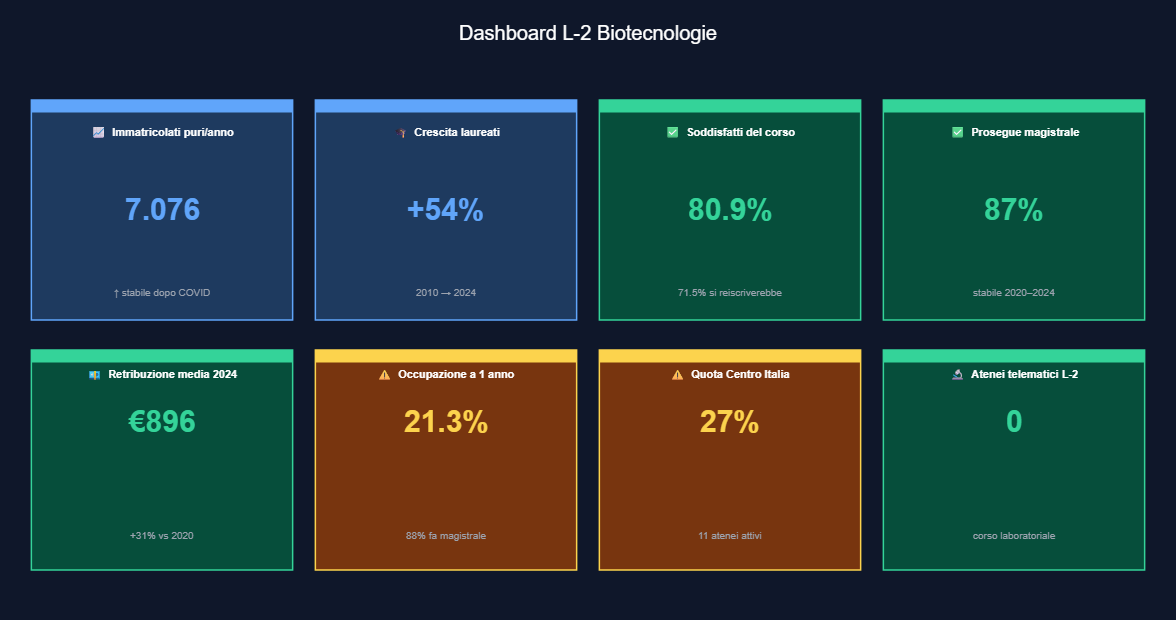

In [7]:
# ── G7 — Dashboard Scorecard finale per il CdA ───────────────────────────

kpi = [
    {'label': 'Immatricolati puri/anno',  'value': '7.076',  'delta': '↑ stabile dopo COVID',          'color': '#60A5FA', 'bg': '#1E3A5F', 'icon': '📈'},
    {'label': 'Crescita laureati',         'value': '+54%',   'delta': '2010 → 2024',                   'color': '#60A5FA', 'bg': '#1E3A5F', 'icon': '🎓'},
    {'label': 'Soddisfatti del corso',     'value': '80.9%',  'delta': '71.5% si reiscriverebbe',       'color': '#34D399', 'bg': '#064E3B', 'icon': '✅'},
    {'label': 'Prosegue magistrale',       'value': '87%',    'delta': 'stabile 2020–2024',             'color': '#34D399', 'bg': '#064E3B', 'icon': '✅'},
    {'label': 'Retribuzione media 2024',   'value': '€896',   'delta': '+31% vs 2020',                  'color': '#34D399', 'bg': '#064E3B', 'icon': '💶'},
    {'label': 'Occupazione a 1 anno',      'value': '21.3%',  'delta': '88% fa magistrale',             'color': '#FCD34D', 'bg': '#78350F', 'icon': '⚠️'},
    {'label': 'Quota Centro Italia',       'value': '27%',    'delta': '11 atenei attivi',              'color': '#FCD34D', 'bg': '#78350F', 'icon': '⚠️'},
    {'label': 'Atenei telematici L-2',     'value': '0',      'delta': 'corso laboratoriale',           'color': '#34D399', 'bg': '#064E3B', 'icon': '🔬'},
]

fig7 = go.Figure()

col_positions = [0.01, 0.26, 0.51, 0.76]
row_positions  = [0.52, 0.02]
cell_w = 0.23
cell_h = 0.44

shapes = []
annotations = []

for idx, k in enumerate(kpi):
    r = idx // 4
    c = idx % 4
    x0 = col_positions[c]
    x1 = x0 + cell_w
    y0 = row_positions[r]
    y1 = y0 + cell_h
    cx = (x0 + x1) / 2

    # Box scuro
    shapes.append(dict(
        type='rect',
        xref='paper', yref='paper',
        x0=x0, x1=x1, y0=y0, y1=y1,
        fillcolor=k['bg'],
        line=dict(color=k['color'], width=1.5),
        layer='below'
    ))

    # Linea accent in cima
    shapes.append(dict(
        type='rect',
        xref='paper', yref='paper',
        x0=x0, x1=x1,
        y0=y1 - 0.025, y1=y1,
        fillcolor=k['color'],
        line=dict(width=0),
        layer='above'
    ))

    # Icona + Label
    annotations.append(dict(
        x=cx, y=y1 - 0.048,
        xref='paper', yref='paper',
        text=f"{k['icon']}  <b>{k['label']}</b>",
        showarrow=False,
        font=dict(size=11, color='white', family='Arial'),
        align='center', xanchor='center'
    ))

    # Valore grande
    annotations.append(dict(
        x=cx, y=(y0 + y1) / 2 + 0.04,
        xref='paper', yref='paper',
        text=f"<b>{k['value']}</b>",
        showarrow=False,
        font=dict(size=30, color=k['color'], family='Arial'),
        align='center', xanchor='center'
    ))

    # Delta
    annotations.append(dict(
        x=cx, y=y0 + 0.055,
        xref='paper', yref='paper',
        text=k['delta'],
        showarrow=False,
        font=dict(size=10, color='#9CA3AF', family='Arial'),
        align='center', xanchor='center'
    ))

fig7.update_layout(
    title=dict(
        text='Dashboard L-2 Biotecnologie',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    shapes=shapes,
    annotations=annotations,
    height=620,
    margin=dict(t=80, b=40, l=20, r=20),
    paper_bgcolor='#0F172A',
    plot_bgcolor='#0F172A',
    xaxis=dict(visible=False, range=[0, 1]),
    yaxis=dict(visible=False, range=[0, 1]),
)

fig7.show()

In [8]:
df_anvur = pd.read_csv('PENTAHO(L2).csv', sep=None, engine='python', encoding='latin-1')

# Converti numeratore
df_anvur['imm'] = df_anvur['Numeratore'].str.replace(',', '').str.replace('.000', '').astype(float)

# Pulisci nome corso
df_anvur['corso_nome'] = df_anvur['Nome Corso'].str.split(' - ', n=1).str[1].str.strip()

# Pulisci ateneo
df_anvur['ateneo_clean'] = df_anvur['Ateneo'].str.strip()

print(f'Righe: {len(df_anvur)}')
print(f'Atenei: {df_anvur["ateneo_clean"].nunique()}')
print(f'Varianti corso: {df_anvur["corso_nome"].nunique()}')
print(f'Anni: {sorted(df_anvur["Anno accademico"].unique())}')
print()
print('Varianti disponibili:')
for c in sorted(df_anvur['corso_nome'].unique()):
    print(f'  {c}')

Righe: 567
Atenei: 43
Varianti corso: 16
Anni: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Varianti disponibili:
  BIOTECNOLOGIE
  Bioinformatica
  Bioscienze e Biotecnologia -  Biosciences and Biotechnology
  Biotecnologia
  Biotecnologie
  Biotecnologie Agro-Alimentari e Industriali
  Biotecnologie Industriali per lo Sviluppo Sostenibile
  Biotecnologie Mediche e Farmaceutiche
  Biotecnologie e Analisi Bioinformatiche
  Biotecnologie mediche
  Biotecnologie per la Salute
  Corso di laurea in Biotecnologie Biomolecolari e Industriali
  Genomica
  Ricerca biotecnologica in medicina
  SCIENZE E TECNOLOGIE BIOMOLECOLARI
  Scienze e tecnologie biologiche


In [9]:
# ── G8b — Treemap varianti L-2 ────────────────────────────────────────────

df_var = df_anvur[df_anvur['Anno accademico'] >= 2019].copy()
df_var['corso_nome'] = df_var['corso_nome'].str.title().str.strip()

anni_tree = sorted(df_var['Anno accademico'].unique())

fig8b = go.Figure()

for i, anno in enumerate(anni_tree):
    subset = (
        df_var[df_var['Anno accademico'] == anno]
        .groupby('corso_nome').agg(
            imm=('imm', 'sum'),
            n_atenei=('ateneo_clean', 'nunique')
        ).reset_index()
    )

    fig8b.add_trace(go.Treemap(
        labels=subset['corso_nome'],
        parents=['L-2 Biotecnologie'] * len(subset),
        values=subset['imm'],
        customdata=subset[['n_atenei', 'imm']],
        hovertemplate=(
            '<b>%{label}</b><br>'
            'Immatricolati: <b>%{customdata[1]:,.0f}</b><br>'
            'N° atenei: <b>%{customdata[0]}</b>'
            '<extra></extra>'
        ),
        marker=dict(
            colorscale=[
                [0.0, '#1E3A5F'],
                [0.4, '#2563EB'],
                [0.7, '#60A5FA'],
                [1.0, '#BAE6FD'],
            ],
            colors=subset['n_atenei'],
            colorbar=dict(
                title=dict(text='N° atenei', font=dict(color='#9CA3AF')),
                tickfont=dict(color='#9CA3AF'),
            ),
            showscale=True,
            line=dict(color='#0F172A', width=2),
        ),
        textfont=dict(size=13, color='white', family='Arial'),
        visible=(i == 0),
    ))

# Bottoni anno
buttons = []
for i, anno in enumerate(anni_tree):
    vis = [j == i for j in range(len(anni_tree))]
    buttons.append(dict(
        label=str(anno),
        method='update',
        args=[
            {'visible': vis},
            {'title': dict(
                text=f'Varianti L-2 Biotecnologie — {anno}',
                font=dict(size=20, color='white', family='Arial'),
                x=0.5, xanchor='center'
            )}
        ]
    ))

fig8b.update_layout(
    title=dict(
        text=f'Varianti L-2 Biotecnologie — {anni_tree[0]}',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.5, xanchor='center',
        y=1.10, yanchor='top',
        buttons=buttons,
        bgcolor='#1F2937',
        bordercolor='#3B82F6',
        borderwidth=1,
        font=dict(size=12, family='Arial', color='white'),
        active=0,
        pad=dict(r=6, l=6, t=6, b=6),
    )],
    annotations=[
        dict(
            x=0.5, y=-0.08,
            xref='paper', yref='paper',
            text='Dimensione = immatricolati · Colore = n° atenei · Fonte: ANVUR',
            showarrow=False,
            font=dict(size=11, color='#6B7280'),
            align='center'
        )
    ],
    height=580,
    margin=dict(t=120, b=60, l=20, r=20),
    font=dict(family='Arial', size=12),
    paper_bgcolor='#0F172A',
)

fig8b.show()


In [10]:
print("Colonne disponibili:", list(df_anvur.columns))
print()
print("Atenei unici:", sorted(df_anvur['ateneo_clean'].unique()))

Colonne disponibili: ['Classe', 'Nome Corso', 'Ateneo', 'Anno accademico', 'Descrizione indicatore', 'Numeratore', 'imm', 'corso_nome', 'ateneo_clean']

Atenei unici: ['Bicocca', 'Carlo Bo', 'Federico II', 'La Sapienza', 'Magna Graecia', 'Piemonte Orientale', 'San Raffaele', 'Tor Vergata', 'UniversitÃ\xa0 Vanvitelli', "UniversitÃ\xa0 de L'Aquila", 'UniversitÃ\xa0 del SALENTO', 'UniversitÃ\xa0 del Sannio', "UniversitÃ\xa0 dell'Insubria", 'UniversitÃ\xa0 della Basilicata', 'UniversitÃ\xa0 della Calabria', 'UniversitÃ\xa0 della Tuscia', 'UniversitÃ\xa0 di Bari', 'UniversitÃ\xa0 di Bologna', 'UniversitÃ\xa0 di Brescia', 'UniversitÃ\xa0 di Cagliari', 'UniversitÃ\xa0 di Camerino', 'UniversitÃ\xa0 di Catania', 'UniversitÃ\xa0 di Ferrara', 'UniversitÃ\xa0 di Firenze', 'UniversitÃ\xa0 di Foggia', 'UniversitÃ\xa0 di Genova', 'UniversitÃ\xa0 di Messina', 'UniversitÃ\xa0 di Milano', 'UniversitÃ\xa0 di Modena e Reggio Emilia', 'UniversitÃ\xa0 di Padova', 'UniversitÃ\xa0 di Palermo', 'UniversitÃ\xa0

In [11]:
# Fix encoding ateneo
df_anvur['ateneo_clean'] = (
    df_anvur['Ateneo']
    .str.encode('latin-1').str.decode('utf-8', errors='replace')
    .str.replace('Università', 'Università')
    .str.strip()
)

# Rimuovi "Università di " per avere solo il nome città
df_anvur['ateneo_short'] = (
    df_anvur['ateneo_clean']
    .str.replace("Università di ", "", regex=False)
    .str.replace("Università della ", "", regex=False)
    .str.replace("Università del ", "", regex=False)
    .str.replace("Università degli Studi di ", "", regex=False)
    .str.replace("Università", "", regex=False)
    .str.strip()
)

print(sorted(df_anvur['ateneo_short'].unique()))

['Bari', 'Basilicata', 'Bicocca', 'Bologna', 'Brescia', 'Cagliari', 'Calabria', 'Camerino', 'Carlo Bo', 'Catania', 'Federico II', 'Ferrara', 'Firenze', 'Foggia', 'Genova', 'La Sapienza', 'Magna Graecia', 'Messina', 'Milano', 'Modena e Reggio Emilia', 'Padova', 'Palermo', 'Parma', 'Pavia', 'Perugia', 'Piemonte Orientale', 'Pisa', 'SALENTO', 'San Raffaele', 'Sannio', 'Sassari', 'Siena', 'Teramo', 'Tor Vergata', 'Torino', 'Trento', 'Trieste', 'Tuscia', 'Udine', 'Vanvitelli', 'Verona', "de L'Aquila", "dell'Insubria"]


Non classificati: []



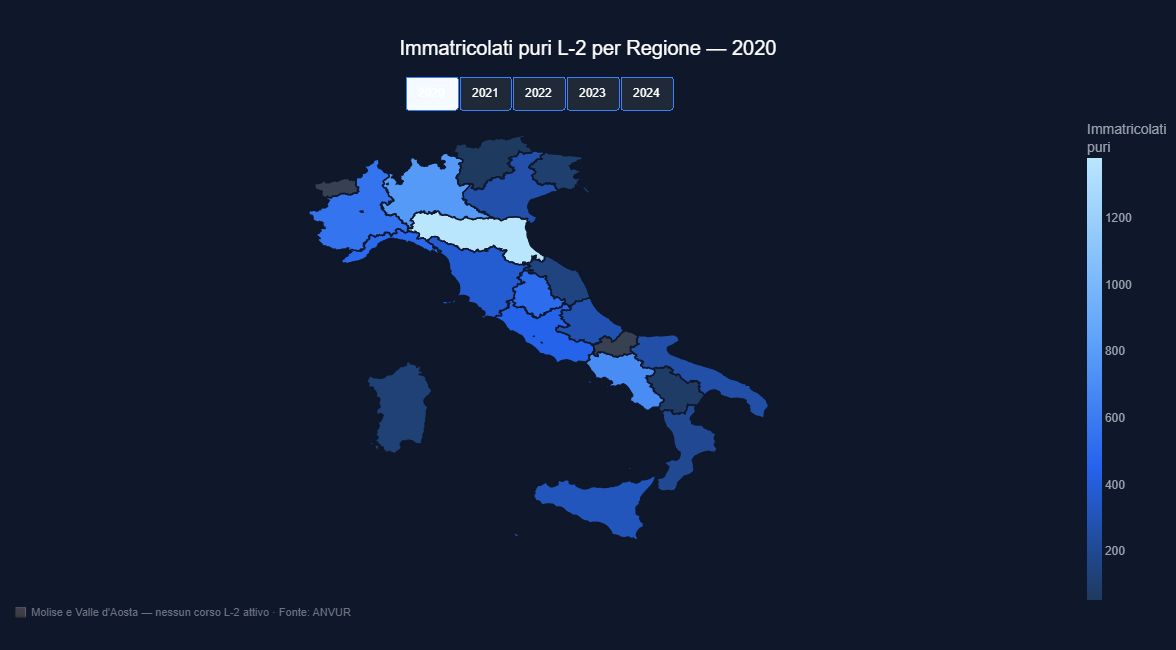

In [63]:
# Lookup ateneo_short → regione
ATENEO_REG_ANVUR = {
    'Torino': 'Piemonte', 'Piemonte Orientale': 'Piemonte',
    'Milano': 'Lombardia', 'Bicocca': 'Lombardia',
    'San Raffaele': 'Lombardia', 'Pavia': 'Lombardia',
    'Brescia': 'Lombardia', "dell'Insubria": 'Lombardia',
    'Trento': 'Trentino-Alto Adige/Südtirol',
    'Padova': 'Veneto', 'Verona': 'Veneto',
    'Trieste': 'Friuli-Venezia Giulia', 'Udine': 'Friuli-Venezia Giulia',
    'Genova': 'Liguria',
    'Bologna': 'Emilia-Romagna', 'Ferrara': 'Emilia-Romagna',
    'Modena e Reggio Emilia': 'Emilia-Romagna', 'Parma': 'Emilia-Romagna',
    'Firenze': 'Toscana', 'Pisa': 'Toscana', 'Siena': 'Toscana',
    'Perugia': 'Umbria',
    'Camerino': 'Marche', 'Carlo Bo': 'Marche',
    'La Sapienza': 'Lazio', 'Tor Vergata': 'Lazio',
    'Tuscia': 'Lazio', 'Teramo': 'Abruzzo', "de L'Aquila": 'Abruzzo',
    'Federico II': 'Campania', 'Vanvitelli': 'Campania', 'Sannio': 'Campania',
    'Bari': 'Puglia', 'Foggia': 'Puglia', 'SALENTO': 'Puglia',
    'Basilicata': 'Basilicata',
    'Calabria': 'Calabria', 'Magna Graecia': 'Calabria',
    'Catania': 'Sicilia', 'Palermo': 'Sicilia', 'Messina': 'Sicilia',
    'Cagliari': 'Sardegna', 'Sassari': 'Sardegna',
}

df_anvur['regione'] = df_anvur['ateneo_short'].map(ATENEO_REG_ANVUR)

# Verifica non classificati
nc = df_anvur[df_anvur['regione'].isna()]['ateneo_short'].unique()
print(f'Non classificati: {nc}')
print()

# Aggregazione per mappa
df_mappa_anvur = (
    df_anvur[
        (df_anvur['Anno accademico'] >= 2020) &
        (df_anvur['regione'].notna())
    ]
    .groupby(['Anno accademico', 'regione'])['imm']
    .sum().reset_index()
    .rename(columns={'imm': 'immatricolati'})
)

# Hover
df_hover_anvur = (
    df_anvur[
        (df_anvur['Anno accademico'] >= 2020) &
        (df_anvur['regione'].notna())
    ]
    .groupby(['Anno accademico', 'regione', 'ateneo_short', 'corso_nome'])['imm']
    .sum().reset_index()
)

def crea_hover_anvur(regione, anno):
    subset = df_hover_anvur[
        (df_hover_anvur['regione'] == regione) &
        (df_hover_anvur['Anno accademico'] == anno)
    ].sort_values('imm', ascending=False)
    totale = int(subset['imm'].sum())
    testo = f"<b>{regione}</b><br>Anno: {anno}<br>Immatricolati puri: <b>{totale:,}</b><br><br>"
    for _, row in subset.iterrows():
        testo += f"🎓 <b>{row['ateneo_short']}</b><br>"
        testo += f"&nbsp;&nbsp;{row['corso_nome']}: {int(row['imm']):,}<br>"
    return testo

df_mappa_anvur['hover'] = df_mappa_anvur.apply(
    lambda r: crea_hover_anvur(r['regione'], r['Anno accademico']), axis=1
)

anni_mappa = sorted(df_mappa_anvur['Anno accademico'].unique())
z_min = df_mappa_anvur['immatricolati'].min()
z_max = df_mappa_anvur['immatricolati'].max()

fig3 = go.Figure()

for i, anno in enumerate(anni_mappa):
    subset = df_mappa_anvur[df_mappa_anvur['Anno accademico'] == anno]

    fig3.add_trace(go.Choropleth(
        geojson=GEOJSON_URL,
        locations=subset['regione'],
        featureidkey='properties.reg_name',
        z=subset['immatricolati'],
        colorscale=[
            [0.0, '#1E3A5F'],
            [0.3, '#2563EB'],
            [0.6, '#60A5FA'],
            [1.0, '#BAE6FD'],
        ],
        zmin=z_min, zmax=z_max,
        colorbar=dict(
            title=dict(text='Immatricolati<br>puri', font=dict(color='#9CA3AF')),
            tickfont=dict(color='#9CA3AF'),
            x=1.0, thickness=15
        ),
        marker_line_color='#0F172A',
        marker_line_width=1.5,
        text=subset['hover'],
        hovertemplate='%{text}<extra></extra>',
        name=str(anno),
        visible=(i == 0),
    ))

    fig3.add_trace(go.Choropleth(
        geojson=GEOJSON_URL,
        locations=GRIGIO_SCURO,
        featureidkey='properties.reg_name',
        z=[0, 0],
        colorscale=[[0, '#374151'], [1, '#374151']],
        showscale=False,
        marker_line_color='#0F172A',
        marker_line_width=1.5,
        hovertemplate='<b>%{location}</b><br>Nessun corso L-2 attivo<extra></extra>',
        visible=(i == 0),
        showlegend=False,
    ))

n_layers = len(fig3.data) // len(anni_mappa)
buttons = []
for i, anno in enumerate(anni_mappa):
    vis = []
    for j in range(len(anni_mappa)):
        for _ in range(n_layers):
            vis.append(j == i)
    buttons.append(dict(
        label=str(anno),
        method='update',
        args=[
            {'visible': vis},
            {'title': dict(
                text=f'Immatricolati puri L-2 per Regione — {anno}',
                font=dict(size=20, color='white', family='Arial'),
                x=0.5, xanchor='center'
            )}
        ]
    ))

fig3.update_layout(
    title=dict(
        text=f'Immatricolati puri L-2 per Regione — {anni_mappa[0]}',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.5, xanchor='center',
        y=1.08, yanchor='top',
        buttons=buttons,
        bgcolor='#1F2937',
        bordercolor='#3B82F6',
        borderwidth=1,
        font=dict(size=12, family='Arial', color='white'),
        active=0,
        pad=dict(r=6, l=6, t=6, b=6),
    )],
    annotations=[
        dict(
            x=0.01, y=-0.02,
            xref='paper', yref='paper',
            text="⬛ Molise e Valle d'Aosta — nessun corso L-2 attivo · Fonte: ANVUR",
            showarrow=False,
            font=dict(size=11, color='#6B7280'),
            align='left'
        )
    ],
    margin=dict(r=20, t=110, l=0, b=40),
    height=650,
    font=dict(family='Arial', size=12),
    paper_bgcolor='#0F172A',
    geo=dict(bgcolor='#0F172A'),
)

fig3.update_geos(fitbounds='locations', visible=False)
fig3.show()

In [13]:
# Top atenei per immatricolati puri — ANVUR
g4_anvur = (
    df_anvur[df_anvur['Anno accademico'] >= 2020]
    .groupby(['Anno accademico', 'ateneo_short', 'regione'])['imm']
    .sum().reset_index()
)

# Aggiungi macro area
g4_anvur['macro'] = g4_anvur['regione'].map({
    'Piemonte': 'Nord', 'Lombardia': 'Nord', 'Veneto': 'Nord',
    'Friuli-Venezia Giulia': 'Nord', 'Liguria': 'Nord',
    'Emilia-Romagna': 'Nord', 'Trentino-Alto Adige/Südtirol': 'Nord',
    'Toscana': 'Centro', 'Umbria': 'Centro', 'Marche': 'Centro',
    'Lazio': 'Centro', 'Abruzzo': 'Centro',
    'Campania': 'Sud', 'Puglia': 'Sud', 'Basilicata': 'Sud',
    'Calabria': 'Sud', 'Molise': 'Sud',
    'Sicilia': 'Isole', 'Sardegna': 'Isole',
})

print('Top 15 atenei 2024:')
top = (
    g4_anvur[g4_anvur['Anno accademico'] == 2024]
    .sort_values('imm', ascending=False)
    .head(15)
)
print(top[['ateneo_short', 'macro', 'imm']].to_string(index=False))

Top 15 atenei 2024:
      ateneo_short  macro   imm
           Ferrara   Nord 781.0
Piemonte Orientale   Nord 631.0
       Federico II    Sud 506.0
           Catania  Isole 478.0
           Perugia Centro 391.0
            Milano   Nord 298.0
           Firenze Centro 224.0
            Padova   Nord 182.0
           Bicocca   Nord 174.0
       La Sapienza Centro 170.0
            Torino   Nord 161.0
              Bari    Sud 139.0
             Pavia   Nord 130.0
            Verona   Nord 126.0
     dell'Insubria   Nord 119.0


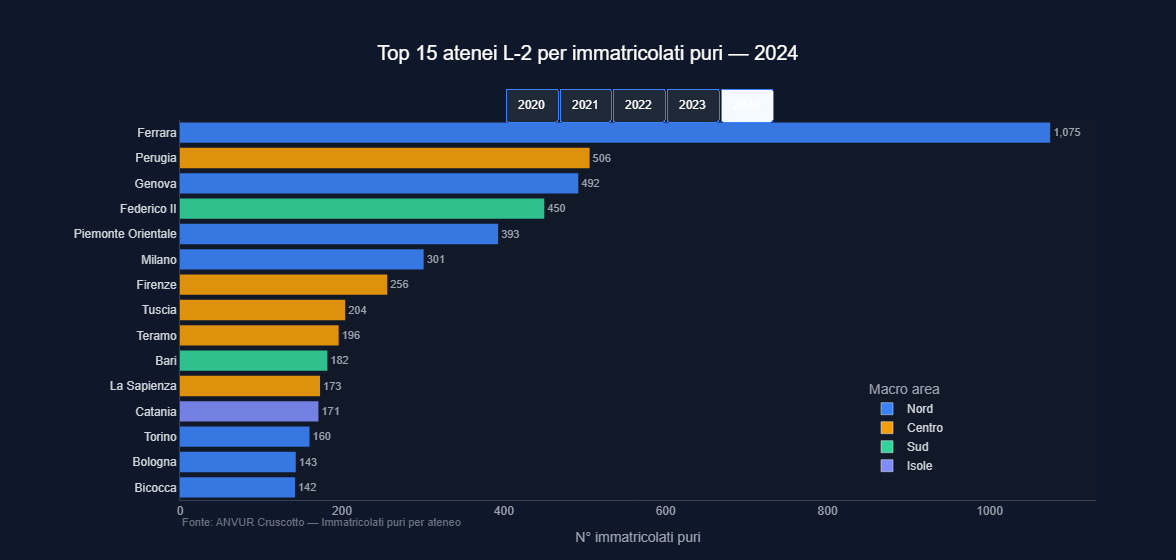

In [37]:
# Aggiungi n° corsi e lista corsi
g4_corsi = (
    df_anvur[df_anvur['Anno accademico'] >= 2020]
    .groupby(['Anno accademico', 'ateneo_short'])['corso_nome']
    .nunique().reset_index()
    .rename(columns={'corso_nome': 'n_corsi'})
)

# Lista corsi con immatricolati per ognuno
g4_nomi = (
    df_anvur[df_anvur['Anno accademico'] >= 2020]
    .groupby(['Anno accademico', 'ateneo_short', 'corso_nome'])['imm']
    .sum().reset_index()
    .groupby(['Anno accademico', 'ateneo_short'])
    .apply(lambda x: '<br>'.join([
        f"&nbsp;&nbsp;• {row['corso_nome']}: <b>{int(row['imm']):,}</b>"
        for _, row in x.sort_values('imm', ascending=False).iterrows()
    ]))
    .reset_index()
    .rename(columns={0: 'lista_corsi'})
)

g4_anvur = (
    df_anvur[df_anvur['Anno accademico'] >= 2020]
    .groupby(['Anno accademico', 'ateneo_short', 'regione'])['imm']
    .sum().reset_index()
)

g4_anvur['macro'] = g4_anvur['regione'].map({
    'Piemonte': 'Nord', 'Lombardia': 'Nord', 'Veneto': 'Nord',
    'Friuli-Venezia Giulia': 'Nord', 'Liguria': 'Nord',
    'Emilia-Romagna': 'Nord', 'Trentino-Alto Adige/Südtirol': 'Nord',
    'Toscana': 'Centro', 'Umbria': 'Centro', 'Marche': 'Centro',
    'Lazio': 'Centro', 'Abruzzo': 'Centro',
    'Campania': 'Sud', 'Puglia': 'Sud', 'Basilicata': 'Sud',
    'Calabria': 'Sud', 'Molise': 'Sud',
    'Sicilia': 'Isole', 'Sardegna': 'Isole',
})

g4_anvur = g4_anvur.merge(g4_corsi, on=['Anno accademico', 'ateneo_short'], how='left')
g4_anvur = g4_anvur.merge(g4_nomi, on=['Anno accademico', 'ateneo_short'], how='left')

# ── Grafico ────────────────────────────────────────────────────────────────
anni_g4 = sorted(g4_anvur['Anno accademico'].unique())

COLORI_MACRO = {
    'Nord'  : '#3B82F6',
    'Centro': '#F59E0B',
    'Sud'   : '#34D399',
    'Isole' : '#818CF8',
}

fig4 = go.Figure()

for i, anno in enumerate(anni_g4):
    subset = (
        g4_anvur[g4_anvur['Anno accademico'] == anno]
        .sort_values('imm', ascending=False)
        .head(15)
        .sort_values('imm', ascending=True)
        .reset_index(drop=True)
    )

    fig4.add_trace(go.Bar(
        x=subset['imm'],
        y=subset['ateneo_short'],
        orientation='h',
        marker=dict(
            color=[COLORI_MACRO.get(m, '#6B7280') for m in subset['macro']],
            line=dict(width=0),
            opacity=0.9
        ),
        text=subset['imm'].astype(int).apply(lambda x: f'{x:,}'),
        textposition='outside',
        textfont=dict(size=11, color='#9CA3AF'),
        customdata=subset[['macro', 'n_corsi', 'lista_corsi']],
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Immatricolati puri: <b>%{x:,}</b><br>'
            'Macro area: %{customdata[0]}<br>'
            'N° corsi L-2: <b>%{customdata[1]}</b><br>'
            '%{customdata[2]}'
            '<extra></extra>'
        ),
        visible=(i == 0),
        showlegend=False,
    ))

# Legenda manuale
for macro, colore in COLORI_MACRO.items():
    fig4.add_trace(go.Bar(
        x=[None], y=[None],
        orientation='h',
        marker_color=colore,
        name=macro,
        visible=True,
    ))

n_trace_dati = len(anni_g4)
n_trace_legenda = len(COLORI_MACRO)

buttons = []
for i, anno in enumerate(anni_g4):
    vis = [j == i for j in range(n_trace_dati)] + [True] * n_trace_legenda
    buttons.append(dict(
        label=str(anno),
        method='update',
        args=[
            {'visible': vis},
            {'title': dict(
                text=f'Top 15 atenei L-2 per immatricolati puri — {anno}',
                font=dict(size=20, color='white', family='Arial'),
                x=0.5, xanchor='center'
            )}
        ]
    ))

fig4.update_layout(
    title=dict(
        text=f'Top 15 atenei L-2 per immatricolati puri — {anni_g4[-1]}',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.5, xanchor='center',
        y=1.10, yanchor='top',
        buttons=buttons,
        bgcolor='#1F2937',
        bordercolor='#3B82F6',
        borderwidth=1,
        font=dict(size=12, family='Arial', color='white'),
        active=len(anni_g4)-1,
        pad=dict(r=6, l=6, t=6, b=6),
    )],
    xaxis=dict(
        title=dict(text='N° immatricolati puri', font=dict(color='#9CA3AF')),
        showgrid=False,
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
    ),
    yaxis=dict(
        showgrid=False,
        tickfont=dict(size=12, color='#D1D5DB'),
        linecolor='#374151',
    ),
    legend=dict(
        title=dict(text='Macro area', font=dict(color='#9CA3AF')),
        font=dict(color='#D1D5DB'),
        bgcolor='rgba(0,0,0,0)',
        x=0.75, y=0.05
    ),
    annotations=[
        dict(
            x=0.0, y=-0.08,
            xref='paper', yref='paper',
            text='Fonte: ANVUR Cruscotto — Immatricolati puri per ateneo',
            showarrow=False,
            font=dict(size=11, color='#6B7280'),
            align='left'
        )
    ],
    height=560,
    margin=dict(t=120, b=60, l=180, r=80),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
    barmode='overlay'
)

fig4.show()

In [15]:
# ── G9 — Trend immatricolati puri atenei L-2 nel Lazio (ANVUR) ────────────

lazio_trend = (
    df_anvur[
        (df_anvur['regione'] == 'Lazio') &
        (df_anvur['Anno accademico'] >= 2019)
    ]
    .groupby(['Anno accademico', 'ateneo_short'])['imm']
    .sum().reset_index()
)

print("Atenei Lazio con L-2:")
print(lazio_trend.groupby('ateneo_short')['imm'].sum().sort_values(ascending=False).to_string())

Atenei Lazio con L-2:
ateneo_short
La Sapienza    1105.0
Tuscia          773.0
Tor Vergata     391.0


In [16]:
print(
    df_anvur[
        (df_anvur['regione'] == 'Lazio') &
        (df_anvur['Anno accademico'] == 2024)
    ][['ateneo_short', 'corso_nome', 'imm']]
    .sort_values(['ateneo_short', 'imm'], ascending=[True, False])
    .to_string(index=False)
)

ateneo_short                                  corso_nome   imm
 La Sapienza                               Biotecnologie 106.0
 La Sapienza Biotecnologie Agro-Alimentari e Industriali  34.0
 La Sapienza                              Bioinformatica  30.0
 Tor Vergata                               Biotecnologie  63.0
      Tuscia                               Biotecnologie  83.0


In [17]:
# ── G9 — Trend immatricolati puri L-2 nel Lazio per ateneo e corso ────────

lazio_detail = (
    df_anvur[
        (df_anvur['regione'] == 'Lazio') &
        (df_anvur['Anno accademico'] >= 2019)
    ]
    .groupby(['Anno accademico', 'ateneo_short', 'corso_nome'])['imm']
    .sum().reset_index()
    .sort_values('Anno accademico')
)

# Label unica ateneo + corso
lazio_detail['label'] = lazio_detail.apply(
    lambda r: f"{r['ateneo_short']} — {r['corso_nome']}", axis=1
)

ordine = (
    lazio_detail.groupby('label')['imm']
    .sum().sort_values(ascending=False).index.tolist()
)

palette = {
    'La Sapienza': ['#F59E0B', '#FCD34D', '#F97316'],
    'Tor Vergata': ['#3B82F6'],
    'Tuscia':      ['#34D399'],
}

# Assegna colori per ateneo
colori_label = {}
contatori = {k: 0 for k in palette}
for label in ordine:
    ateneo = label.split(' — ')[0]
    idx = contatori.get(ateneo, 0)
    colori_label[label] = palette.get(ateneo, ['#818CF8'])[idx % len(palette.get(ateneo, ['#818CF8']))]
    contatori[ateneo] = idx + 1

fig9 = go.Figure()

for label in ordine:
    df_lab = lazio_detail[lazio_detail['label'] == label].sort_values('Anno accademico')
    colore = colori_label[label]
    ateneo = label.split(' — ')[0]
    corso  = label.split(' — ')[1]

    # Linea tratteggiata per corsi secondari Sapienza
    dash = 'dot' if ateneo == 'La Sapienza' and corso != 'Biotecnologie' else 'solid'

    fig9.add_trace(go.Scatter(
        x=df_lab['Anno accademico'].astype(str),
        y=df_lab['imm'],
        mode='lines+markers',
        name=label,
        line=dict(color=colore, width=2.5, dash=dash),
        marker=dict(size=8, color=colore,
                    line=dict(color='#0F172A', width=1.5)),
        hovertemplate=(
            f'<b>{label}</b><br>'
            'Anno: %{x}<br>'
            'Immatricolati puri: <b>%{y:,.0f}</b>'
            '<extra></extra>'
        )
    ))

    # Etichetta ultimo anno
    ultimo = df_lab.iloc[-1]
    fig9.add_annotation(
        x=str(int(ultimo['Anno accademico'])),
        y=ultimo['imm'],
        text=f"<b>{int(ultimo['imm'])}</b>",
        showarrow=False,
        font=dict(size=10, color=colore),
        xanchor='left', xshift=8
    )

fig9.update_layout(
    title=dict(
        text='Immatricolati puri L-2 nel Lazio per ateneo e corso — 2019–2024',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Anno accademico', font=dict(color='#9CA3AF')),
        showgrid=False,
        tickfont=dict(size=11, color='#9CA3AF'),
        linecolor='#374151',
    ),
    yaxis=dict(
        title=dict(text='N° immatricolati puri', font=dict(color='#9CA3AF')),
        gridcolor='#1F2937',
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
        rangemode='tozero'
    ),
    legend=dict(
        font=dict(color='#D1D5DB', size=10),
        bgcolor='rgba(0,0,0,0)',
        x=0.01, y=0.99
    ),
    annotations=[
        dict(
    x=1.0, y=-0.12,
    xref='paper', yref='paper',
    text='Fonte: ANVUR · Le linee tratteggiate indicano corsi che variano da L2-Classica',
    showarrow=False,
    font=dict(size=11, color='#6B7280'),
    align='right',
    xanchor='right'
)
    ],
    height=500,
    margin=dict(t=80, b=80, l=60, r=180),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
)

fig9.show()

In [18]:
# Ricalcola macro in df_anvur
df_anvur['macro'] = df_anvur['regione'].map({
    'Piemonte': 'Nord', 'Lombardia': 'Nord', 'Veneto': 'Nord',
    'Friuli-Venezia Giulia': 'Nord', 'Liguria': 'Nord',
    'Emilia-Romagna': 'Nord', 'Trentino-Alto Adige/Südtirol': 'Nord',
    'Toscana': 'Centro', 'Umbria': 'Centro', 'Marche': 'Centro',
    'Lazio': 'Centro', 'Abruzzo': 'Centro',
    'Campania': 'Sud', 'Puglia': 'Sud', 'Basilicata': 'Sud',
    'Calabria': 'Sud', 'Molise': 'Sud',
    'Sicilia': 'Isole', 'Sardegna': 'Isole',
})

print(df_anvur['macro'].value_counts())

macro
Nord      238
Centro    153
Sud       121
Isole      55
Name: count, dtype: int64


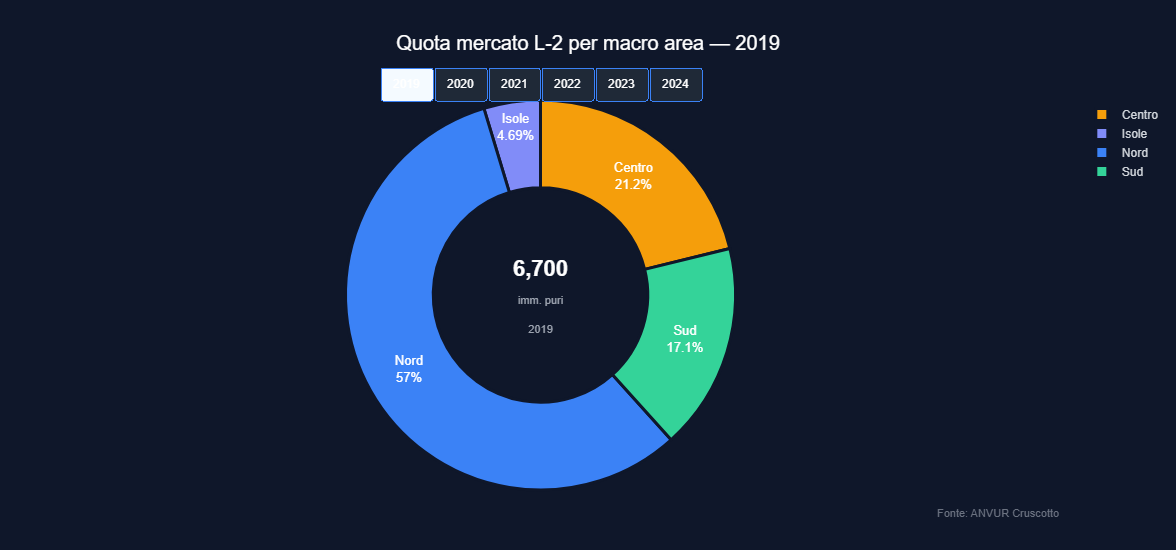

In [19]:
# ── G10 — Donut chart quota mercato L-2 per macro area (ANVUR) ────────────

macro_trend = (
    df_anvur[df_anvur['Anno accademico'] >= 2019]
    .groupby(['Anno accademico', 'macro'])['imm']
    .sum().reset_index()
    .dropna(subset=['macro'])
)

anni_donut = sorted(macro_trend['Anno accademico'].unique())

COLORI_MACRO_DONUT = {
    'Nord'  : '#3B82F6',
    'Centro': '#F59E0B',
    'Sud'   : '#34D399',
    'Isole' : '#818CF8',
}

fig10 = go.Figure()

for i, anno in enumerate(anni_donut):
    subset = macro_trend[macro_trend['Anno accademico'] == anno].copy()
    subset['pct'] = (subset['imm'] / subset['imm'].sum() * 100).round(1)
    totale = int(subset['imm'].sum())

    fig10.add_trace(go.Pie(
        labels=subset['macro'],
        values=subset['imm'],
        hole=0.55,
        marker=dict(
            colors=[COLORI_MACRO_DONUT.get(m, '#6B7280') for m in subset['macro']],
            line=dict(color='#0F172A', width=3)
        ),
        textinfo='label+percent',
        textfont=dict(size=13, color='white', family='Arial'),
        hovertemplate=(
            '<b>%{label}</b><br>'
            'Immatricolati puri: <b>%{value:,}</b><br>'
            'Quota: <b>%{percent}</b>'
            '<extra></extra>'
        ),
        visible=(i == 0),
        sort=False,
    ))

    # Testo centrale — totale anno
    if i == 0:
        fig10.add_annotation(
            text=f"<b>{totale:,}</b><br><span style='font-size:11px;color:#9CA3AF'>imm. puri<br>{anno}</span>",
            x=0.5, y=0.5,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=22, color='white', family='Arial'),
            align='center'
        )

# Bottoni anno
buttons = []
for i, anno in enumerate(anni_donut):
    subset = macro_trend[macro_trend['Anno accademico'] == anno]
    totale = int(subset['imm'].sum())
    vis = [j == i for j in range(len(anni_donut))]
    buttons.append(dict(
        label=str(anno),
        method='update',
        args=[
            {'visible': vis},
            {
                'title': dict(
                    text=f'Quota mercato L-2 per macro area — {anno}',
                    font=dict(size=20, color='white', family='Arial'),
                    x=0.5, xanchor='center'
                ),
                'annotations': [dict(
                    text=f"<b>{totale:,}</b><br><span style='font-size:11px;color:#9CA3AF'>imm. puri<br>{anno}</span>",
                    x=0.5, y=0.5,
                    xref='paper', yref='paper',
                    showarrow=False,
                    font=dict(size=22, color='white', family='Arial'),
                    align='center'
                ),
                dict(
                    x=1.0, y=-0.08,
                    xref='paper', yref='paper',
                    text='Fonte: ANVUR Cruscotto',
                    showarrow=False,
                    font=dict(size=11, color='#6B7280'),
                    align='right', xanchor='right'
                )]
            }
        ]
    ))

fig10.update_layout(
    title=dict(
        text=f'Quota mercato L-2 per macro area — {anni_donut[0]}',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.5, xanchor='center',
        y=1.10, yanchor='top',
        buttons=buttons,
        bgcolor='#1F2937',
        bordercolor='#3B82F6',
        borderwidth=1,
        font=dict(size=12, family='Arial', color='white'),
        active=0,
        pad=dict(r=6, l=6, t=6, b=6),
    )],
    annotations=[
        dict(
            text=f"<b>{int(macro_trend[macro_trend['Anno accademico']==anni_donut[0]]['imm'].sum()):,}</b><br><span style='font-size:11px;color:#9CA3AF'>imm. puri<br>{anni_donut[0]}</span>",
            x=0.5, y=0.5,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=22, color='white', family='Arial'),
            align='center'
        ),
        dict(
            x=1.0, y=-0.08,
            xref='paper', yref='paper',
            text='Fonte: ANVUR Cruscotto',
            showarrow=False,
            font=dict(size=11, color='#6B7280'),
            align='right', xanchor='right'
        )
    ],
    height=550,
    margin=dict(t=100, b=60, l=20, r=20),
    font=dict(family='Arial', size=12),
    paper_bgcolor='#0F172A',
    showlegend=True,
    legend=dict(
        font=dict(color='#D1D5DB', size=12),
        bgcolor='rgba(0,0,0,0)',
    )
)

fig10.show()

In [20]:
# Confronto MUR vs ANVUR per anno
mur_tot = imm_l2.groupby('AnnoA')['Imm'].sum().reset_index()
mur_tot['anno'] = mur_tot['AnnoA'].str[:4].astype(int)
mur_tot = mur_tot[mur_tot['anno'] >= 2019][['anno', 'Imm']].rename(columns={'Imm': 'MUR'})

anvur_tot = (
    df_anvur[df_anvur['Anno accademico'] >= 2019]
    .groupby('Anno accademico')['imm']
    .sum().reset_index()
    .rename(columns={'Anno accademico': 'anno', 'imm': 'ANVUR'})
)

confronto = mur_tot.merge(anvur_tot, on='anno')
confronto['differenza'] = confronto['MUR'] - confronto['ANVUR']
confronto['diff_pct'] = (confronto['differenza'] / confronto['MUR'] * 100).round(1)

print(confronto.to_string(index=False))

 anno  MUR  ANVUR  differenza  diff_pct
 2019 7089 6700.0       389.0       5.5
 2020 7884 7051.0       833.0      10.6
 2021 7688 6620.0      1068.0      13.9
 2022 6785 6218.0       567.0       8.4
 2023 6944 6602.0       342.0       4.9
 2024 7076 6615.0       461.0       6.5


In [21]:
# Controlliamo la descrizione indicatore nel file ANVUR
print("Descrizione indicatore ANVUR:")
print(df_anvur['Descrizione indicatore'].unique())
print()

# Controlliamo il nome esatto della colonna MUR
print("Nome colonna MUR immatricolati:")
print(df_imm.columns.tolist())
print()

# Controlliamo le prime righe del file MUR originale
print("Prime righe MUR:")
print(df_imm[df_imm['ClasseNUMERO'].astype(str).str.strip() == 'L-2'].head(5).to_string(index=False))

Descrizione indicatore ANVUR:
['Immatricolati puri ** (L; LMCU)']

Nome colonna MUR immatricolati:
['AnnoA', 'ClasseNUMERO', 'ClasseNOME', 'Sesso', 'Imm']

Prime righe MUR:
    AnnoA ClasseNUMERO    ClasseNOME Sesso  Imm
2024/2025          L-2 Biotecnologie     F 4912
2024/2025          L-2 Biotecnologie     M 2164
2023/2024          L-2 Biotecnologie     F 5015
2023/2024          L-2 Biotecnologie     M 1929
2022/2023          L-2 Biotecnologie     F 4816


In [22]:
# Atenei presenti in MUR iscritti 1° anno (proxy copertura)
mur_atenei = anno1_l2['AteneoNOME'].nunique()
anvur_atenei = df_anvur['ateneo_short'].nunique()

print(f"Atenei in MUR (iscritti 1° anno): {mur_atenei}")
print(f"Atenei in ANVUR: {anvur_atenei}")
print()

# Quali atenei MUR non sono in ANVUR?
mur_set = set(anno1_l2['AteneoNOME'].str.strip().unique())
anvur_set = set(df_anvur['ateneo_clean'].str.strip().unique())

print("Atenei in MUR ma NON in ANVUR:")
for a in sorted(mur_set):
    trovato = any(a.lower() in x.lower() or x.lower() in a.lower() for x in anvur_set)
    if not trovato:
        isc = int(anno1_l2[anno1_l2['AteneoNOME']==a]['Isc'].sum())
        print(f"  {a}: {isc:,} iscritti totali")

Atenei in MUR (iscritti 1° anno): 44
Atenei in ANVUR: 43

Atenei in MUR ma NON in ANVUR:
  Catanzaro: 1,249 iscritti totali
  Milano Cattolica: 233 iscritti totali
  Napoli Vanvitelli: 1,411 iscritti totali
  Urbino: 1,235 iscritti totali


In [23]:
import subprocess
result = subprocess.run(['streamlit', '--version'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Streamlit, version 1.51.0




In [24]:
import os
print("File nella cartella di lavoro:")
for f in sorted(os.listdir('.')):
    print(f'  {f}')

File nella cartella di lavoro:
  .ipynb_checkpoints
  .virtual_documents
  ALMALAUREA_occupazione
  ANALISI_L2.ipynb
  L2_datadest.csv
  L2_presentazione.ipynb
  MUR_laureatixclasse.csv
  MURimmatricolatixclasse.csv
  MURiscritti1annoxateneo.csv
  MURiscrittixclasse.csv
  MURiscrittixcorsodistudi.csv
  PENTAHO(L2).csv
  PROJECT.ipynb
  Untitled.ipynb
  Untitled2.ipynb
  almalaurea_2024_clean.csv
  anaconda_projects
  datialmalaureaOCCUPAZIONE2020.csv
  datialmalaureaOCCUPAZIONE2021.csv
  datialmalaureaOCCUPAZIONE2022.csv
  datialmalaureaOCCUPAZIONE2023.csv
  datialmalaureaOCCUPAZIONE2024.csv
  datialmalaureaPROFILO2020.csv
  datialmalaureaPROFILO2021.csv
  datialmalaureaPROFILO2022.csv
  datialmalaureaPROFILO2023.csv
  datialmalaureaPROFILO2024.csv
  grafici.ipynb
  test.ipynb


In [25]:
import pandas as pd

df_ava2 = pd.read_csv('L2_datadest.csv', sep=';', encoding='latin-1')

print(f'Righe: {len(df_ava2)}')
print(f'Anni: {sorted(df_ava2["ID_ANNO_ACCADEMICO"].unique())}')
print(f'Atenei: {df_ava2["CODE_UN"].nunique()}')
print(f'Corsi: {df_ava2["NOME_CORSO"].nunique()}')
print()

for codice in ['iC14', 'iC24', 'iC21']:
    subset = df_ava2[df_ava2['CODICE'] == codice]
    print(f'{codice} — righe disponibili: {len(subset)}')
    print(subset[['NOME_CORSO','CODE_UN','ID_ANNO_ACCADEMICO','NUMERATORE','DENOMINATORE','INDICATORE']].head(3).to_string(index=False))
    print()

Righe: 8636
Anni: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Atenei: 43
Corsi: 16

iC14 — righe disponibili: 196
                                           NOME_CORSO CODE_UN  ID_ANNO_ACCADEMICO NUMERATORE DENOMINATORE                                INDICATORE
Biotecnologie Industriali per lo Sviluppo Sostenibile      02                2020         19           84 ,2261904761904761904761904761904761904762
Biotecnologie Industriali per lo Sviluppo Sostenibile      02                2021         13           90 ,1444444444444444444444444444444444444444
Biotecnologie Industriali per lo Sviluppo Sostenibile      02                2022         12           84 ,1428571428571428571428571428571428571429

iC24 — righe disponibili: 193
                                           NOME_CORSO CODE_UN  ID_ANNO_ACCADEMICO NUMERATORE DENOMINATORE                                INDICATORE
Biotecnologie Industriali per lo Sviluppo Sostenibile      02                2

In [26]:
# Pulizia colonna INDICATORE
df_ava2['ind_float'] = (
    df_ava2['INDICATORE']
    .astype(str)
    .str.strip()
    .str.replace(',', '.')
    .str.replace(' ', '')
    .apply(lambda x: float(x) if x not in ['', 'nan', 'None'] else None)
)

# Verifica iC14
ic14 = df_ava2[df_ava2['CODICE'] == 'iC14'].copy()
print(f'iC14 — righe: {len(ic14)}')
print(f'Range valori: {ic14["ind_float"].min():.1f} — {ic14["ind_float"].max():.1f}')
print(f'Media nazionale per anno:')
print(ic14.groupby('ID_ANNO_ACCADEMICO')['ind_float'].mean().round(1).to_string())
print()

# Verifica iC24
ic24 = df_ava2[df_ava2['CODICE'] == 'iC24'].copy()
print(f'iC24 — righe: {len(ic24)}')
print(f'Range valori: {ic24["ind_float"].min():.1f} — {ic24["ind_float"].max():.1f}')
print(f'Media nazionale per anno:')
print(ic24.groupby('ID_ANNO_ACCADEMICO')['ind_float'].mean().round(1).to_string())
print()

# Verifica per variante
print('iC14 media per variante corso (tutti gli anni):')
print(ic14.groupby('NOME_CORSO')['ind_float'].mean().round(1).sort_values(ascending=False).to_string())

iC14 — righe: 196
Range valori: 0.1 — 0.9
Media nazionale per anno:
ID_ANNO_ACCADEMICO
2020    0.5
2021    0.5
2022    0.5
2023    0.6

iC24 — righe: 193
Range valori: 0.1 — 0.9
Media nazionale per anno:
ID_ANNO_ACCADEMICO
2020    0.5
2021    0.5
2022    0.5
2023    0.5

iC14 media per variante corso (tutti gli anni):
NOME_CORSO
Genomica                                                        0.9
Ricerca biotecnologica in medicina                              0.8
SCIENZE E TECNOLOGIE BIOMOLECOLARI                              0.8
Bioinformatica                                                  0.7
Bioscienze e Biotecnologia -  Biosciences and Biotechnology     0.7
Biotecnologie Agro-Alimentari e Industriali                     0.7
BIOTECNOLOGIE                                                   0.6
Biotecnologia                                                   0.6
Biotecnologie mediche                                           0.6
Scienze e tecnologie biologiche                          

In [27]:
# Verifica con un caso specifico
esempio = df_ava2[
    (df_ava2['CODICE'] == 'iC14') &
    (df_ava2['NOME_CORSO'] == 'Biotecnologie') &
    (df_ava2['ID_ANNO_ACCADEMICO'] == 2022)
][['NOME_CORSO', 'CODE_UN', 'NUMERATORE', 'DENOMINATORE', 'INDICATORE', 'ind_float']]
print(esempio.to_string(index=False))

   NOME_CORSO CODE_UN NUMERATORE DENOMINATORE                                INDICATORE  ind_float
Biotecnologie      03         60           89 ,6741573033707865168539325842696629213483   0.674157
Biotecnologie      08         58          134 ,4328358208955223880597014925373134328358   0.432836
Biotecnologie      09        130          264 ,4924242424242424242424242424242424242424   0.492424
Biotecnologie      10         84          249 ,3373493975903614457831325301204819277108   0.337349
Biotecnologie      11         32           90 ,3555555555555555555555555555555555555556   0.355556
Biotecnologie      14         44           99 ,4444444444444444444444444444444444444444   0.444444
Biotecnologie      19        114          183 ,6229508196721311475409836065573770491803   0.622951
Biotecnologie      20         39           68 ,5735294117647058823529411764705882352941   0.573529
Biotecnologie      21         68           88 ,7727272727272727272727272727272727272727   0.772727
Biotecnolo

In [28]:
# Prepara dati opzione A
ic14_naz = ic14.groupby('ID_ANNO_ACCADEMICO')['ind_float'].mean().reset_index()
ic14_naz['pct'] = (ic14_naz['ind_float'] * 100).round(1)

ic24_naz = ic24.groupby('ID_ANNO_ACCADEMICO')['ind_float'].mean().reset_index()
ic24_naz['pct'] = (ic24_naz['ind_float'] * 100).round(1)

print('iC14 — Prosecuzione al 2° anno (%):')
print(ic14_naz[['ID_ANNO_ACCADEMICO','pct']].to_string(index=False))
print()
print('iC24 — Abbandoni (%):')
print(ic24_naz[['ID_ANNO_ACCADEMICO','pct']].to_string(index=False))

iC14 — Prosecuzione al 2° anno (%):
 ID_ANNO_ACCADEMICO  pct
               2020 54.6
               2021 53.2
               2022 51.6
               2023 55.4

iC24 — Abbandoni (%):
 ID_ANNO_ACCADEMICO  pct
               2020 46.5
               2021 49.0
               2022 49.5
               2023 50.7


In [29]:
ic21 = df_ava2[df_ava2['CODICE'] == 'iC21'].copy()
ic21['ind_float'] = (
    ic21['INDICATORE'].astype(str).str.strip()
    .str.replace(',', '.').str.replace(' ', '')
    .apply(lambda x: float(x) if x not in ['', 'nan', 'None'] else None)
)
ic21_naz = ic21.groupby('ID_ANNO_ACCADEMICO')['ind_float'].mean().reset_index()
ic21_naz['pct'] = (ic21_naz['ind_float'] * 100).round(1)

print('iC21 — Prosecuzione nel sistema universitario (%):')
print(ic21_naz[['ID_ANNO_ACCADEMICO','pct']].to_string(index=False))

iC21 — Prosecuzione nel sistema universitario (%):
 ID_ANNO_ACCADEMICO  pct
               2020 86.7
               2021 86.1
               2022 86.6
               2023 90.1


anno  prosegue_stesso  cambia_corso  abbandona
2020             54.6          32.1       13.3
2021             53.2          32.9       13.9
2022             51.6          35.0       13.4
2023             55.4          34.7        9.9


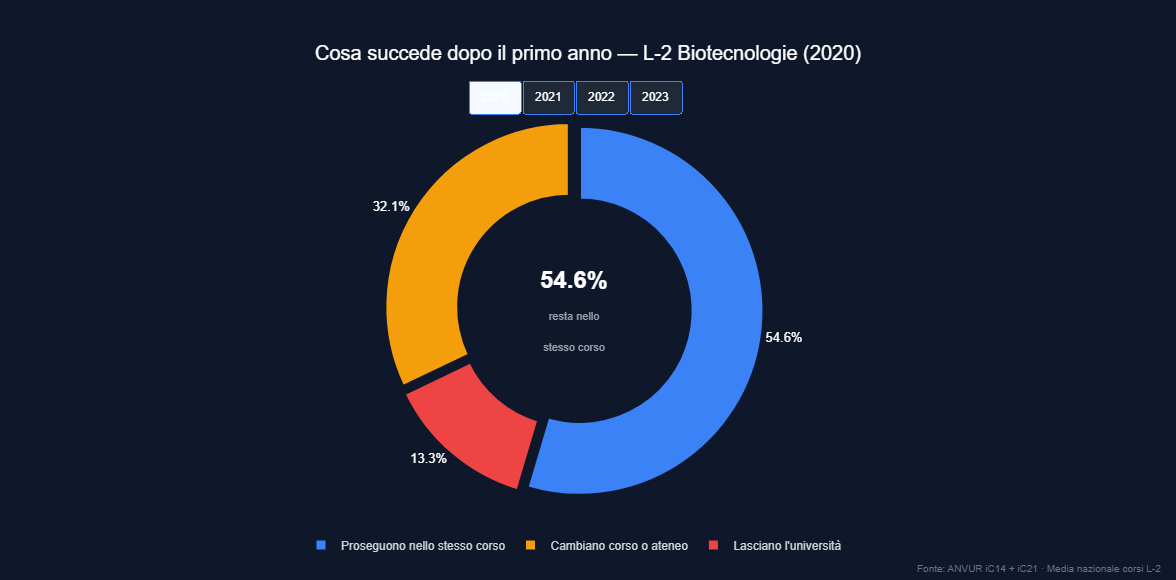

In [60]:
import plotly.graph_objects as go

# ── Preparazione dati ─────────────────────────────────────────────────────

ic14 = df_ava2[df_ava2['CODICE'] == 'iC14'].copy()
ic21 = df_ava2[df_ava2['CODICE'] == 'iC21'].copy()

for df_ind in [ic14, ic21]:
    df_ind['ind_float'] = (
        df_ind['INDICATORE'].astype(str).str.strip()
        .str.replace(',', '.').str.replace(' ', '')
        .apply(lambda x: float(x) if x not in ['', 'nan', 'None'] else None)
    )

ic14_naz = ic14.groupby('ID_ANNO_ACCADEMICO')['ind_float'].mean().reset_index()
ic14_naz.columns = ['anno', 'ic14']

ic21_naz = ic21.groupby('ID_ANNO_ACCADEMICO')['ind_float'].mean().reset_index()
ic21_naz.columns = ['anno', 'ic21']

df_destino = ic14_naz.merge(ic21_naz, on='anno')
df_destino['prosegue_stesso'] = (df_destino['ic14'] * 100).round(1)
df_destino['cambia_corso']    = ((df_destino['ic21'] - df_destino['ic14']) * 100).round(1)
df_destino['abbandona']       = ((1 - df_destino['ic21']) * 100).round(1)
df_destino['anno'] = df_destino['anno'].astype(str)

anni_g11 = sorted(df_destino['anno'].unique())

print(df_destino[['anno','prosegue_stesso','cambia_corso','abbandona']].to_string(index=False))

# ── Grafico ───────────────────────────────────────────────────────────────

fig11 = go.Figure()

for i, anno in enumerate(anni_g11):
    row = df_destino[df_destino['anno'] == anno].iloc[0]

    fig11.add_trace(go.Pie(
        labels=[
            'Proseguono nello stesso corso',
            'Cambiano corso o ateneo',
            'Lasciano l\'università'
        ],
        values=[
            row['prosegue_stesso'],
            row['cambia_corso'],
            row['abbandona']
        ],
        hole=0.60,
        marker=dict(
            colors=['#3B82F6', '#F59E0B', '#EF4444'],
            line=dict(color='#0F172A', width=3)
        ),
        textinfo='percent',
        textposition='outside',
        textfont=dict(size=13, color='white', family='Arial'),
        hovertemplate=(
            '<b>%{label}</b><br>'
            '<b>%{value:.1f}%</b> degli immatricolati'
            '<extra></extra>'
        ),
        visible=(i == 0),
        sort=False,
        pull=[0.03, 0.03, 0.03],
    ))

buttons = []
for i, anno in enumerate(anni_g11):
    row = df_destino[df_destino['anno'] == anno].iloc[0]
    vis = [j == i for j in range(len(anni_g11))]
    buttons.append(dict(
        label=anno,
        method='update',
        args=[
            {'visible': vis},
            {
                'title': dict(
                    text=f'Cosa succede dopo il primo anno — L-2 Biotecnologie ({anno})',
                    font=dict(size=20, color='white', family='Arial'),
                    x=0.5, xanchor='center'
                ),
                'annotations': [
                    dict(
                        text=f"<b>{row['prosegue_stesso']:.1f}%</b>"
                             f"<br><span style='color:#9CA3AF;font-size:11px'>resta nello<br>stesso corso</span>",
                        x=0.5, y=0.5,
                        xref='paper', yref='paper',
                        showarrow=False,
                        font=dict(size=24, color='white', family='Arial'),
                        align='center'
                    ),
                    dict(
                        x=1.0, y=-0.12,
                        xref='paper', yref='paper',
                        text='Fonte: ANVUR iC14 + iC21 · Media nazionale corsi L-2',
                        showarrow=False,
                        font=dict(size=10, color='#6B7280'),
                        align='right', xanchor='right'
                    )
                ]
            }
        ]
    ))

row0 = df_destino[df_destino['anno'] == anni_g11[0]].iloc[0]

fig11.update_layout(
    title=dict(
        text=f'Cosa succede dopo il primo anno — L-2 Biotecnologie ({anni_g11[0]})',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    updatemenus=[dict(
        type='buttons',
        direction='right',
        x=0.5, xanchor='center',
        y=1.12, yanchor='top',
        buttons=buttons,
        bgcolor='#1F2937',
        bordercolor='#3B82F6',
        borderwidth=1,
        font=dict(size=12, family='Arial', color='white'),
        active=0,
        pad=dict(r=6, l=6, t=6, b=6),
    )],
    annotations=[
        dict(
            text=f"<b>{row0['prosegue_stesso']:.1f}%</b>"
                 f"<br><span style='color:#9CA3AF;font-size:11px'>resta nello<br>stesso corso</span>",
            x=0.5, y=0.5,
            xref='paper', yref='paper',
            showarrow=False,
            font=dict(size=24, color='white', family='Arial'),
            align='center'
        ),
        dict(
            x=1.3, y=-0.20,
            xref='paper', yref='paper',
            text='Fonte: ANVUR iC14 + iC21 · Media nazionale corsi L-2',
            showarrow=False,
            font=dict(size=10, color='#6B7280'),
            align='right', xanchor='right'
        )
    ],
    height=580,
    margin=dict(t=120, b=80, l=80, r=80),
    font=dict(family='Arial', size=12),
    paper_bgcolor='#0F172A',
    showlegend=True,
    legend=dict(
        font=dict(color='#D1D5DB', size=12),
        bgcolor='rgba(0,0,0,0)',
        orientation='h',
        x=0.5, xanchor='center',
        y=-0.08
    )
)

fig11.show()

In [46]:
# iC14 per variante corso — media tutti gli anni
ic14_var = ic14.groupby('NOME_CORSO')['ind_float'].mean().reset_index()
ic14_var.columns = ['corso', 'prosecuzione']
ic14_var['abbandono'] = (1 - ic14_var['prosecuzione']) * 100
ic14_var['prosecuzione_pct'] = ic14_var['prosecuzione'] * 100
ic14_var = ic14_var.round(1).sort_values('abbandono', ascending=False)

print('Varianti per tasso abbandono (dal più alto al più basso):')
print(ic14_var[['corso','prosecuzione_pct','abbandono']].to_string(index=False))

Varianti per tasso abbandono (dal più alto al più basso):
                                                       corso  prosecuzione_pct  abbandono
       Biotecnologie Industriali per lo Sviluppo Sostenibile              18.8       81.2
                     Biotecnologie e Analisi Bioinformatiche              31.1       68.9
                                 Biotecnologie per la Salute              36.9       63.1
                       Biotecnologie Mediche e Farmaceutiche              38.0       62.0
Corso di laurea in Biotecnologie Biomolecolari e Industriali              49.6       50.4
                                               Biotecnologie              50.3       49.7
                                               BIOTECNOLOGIE              55.4       44.6
                                       Biotecnologie mediche              57.4       42.6
                                               Biotecnologia              60.2       39.8
                             Scienze e tec

In [47]:
# Normalizza nomi
ic14['corso_norm'] = ic14['NOME_CORSO'].str.title().str.strip()

ic14_var = ic14.groupby('corso_norm')['ind_float'].mean().reset_index()
ic14_var.columns = ['corso', 'prosecuzione']
ic14_var['abbandono'] = ((1 - ic14_var['prosecuzione']) * 100).round(1)
ic14_var['prosecuzione_pct'] = (ic14_var['prosecuzione'] * 100).round(1)
ic14_var = ic14_var.sort_values('abbandono', ascending=False).reset_index(drop=True)

print(ic14_var[['corso','prosecuzione_pct','abbandono']].to_string(index=False))

                                                       corso  prosecuzione_pct  abbandono
       Biotecnologie Industriali Per Lo Sviluppo Sostenibile              18.8       81.2
                     Biotecnologie E Analisi Bioinformatiche              31.1       68.9
                                 Biotecnologie Per La Salute              36.9       63.1
                       Biotecnologie Mediche E Farmaceutiche              38.0       62.0
Corso Di Laurea In Biotecnologie Biomolecolari E Industriali              49.6       50.4
                                               Biotecnologie              51.5       48.5
                                       Biotecnologie Mediche              57.4       42.6
                                               Biotecnologia              60.2       39.8
                             Scienze E Tecnologie Biologiche              63.6       36.4
                 Biotecnologie Agro-Alimentari E Industriali              67.5       32.5
 Bioscienz

In [48]:
# Verifica caso specifico
caso = ic14[ic14['corso_norm'] == 'Biotecnologie Industriali Per Lo Sviluppo Sostenibile']
print(f'N° osservazioni: {len(caso)}')
print(f'Atenei coinvolti: {caso["CODE_UN"].nunique()}')
print()
print(caso[['CODE_UN', 'ID_ANNO_ACCADEMICO', 'NUMERATORE', 'DENOMINATORE', 'ind_float']].to_string(index=False))

N° osservazioni: 4
Atenei coinvolti: 1

CODE_UN  ID_ANNO_ACCADEMICO NUMERATORE DENOMINATORE  ind_float
     02                2020         19           84   0.226190
     02                2021         13           90   0.144444
     02                2022         12           84   0.142857
     02                2023         12           50   0.240000


In [49]:
# Filtra varianti con almeno 3 atenei
ic14_atenei = ic14.groupby('corso_norm')['CODE_UN'].nunique().reset_index()
ic14_atenei.columns = ['corso', 'n_atenei']

ic14_var = ic14_var.merge(ic14_atenei, on='corso')
ic14_var_filt = ic14_var[ic14_var['n_atenei'] >= 3].sort_values('abbandono', ascending=False)

print(f'Varianti con almeno 3 atenei: {len(ic14_var_filt)}')
print()
print(ic14_var_filt[['corso','n_atenei','prosecuzione_pct','abbandono']].to_string(index=False))

Varianti con almeno 3 atenei: 1

        corso  n_atenei  prosecuzione_pct  abbandono
Biotecnologie        33              51.5       48.5


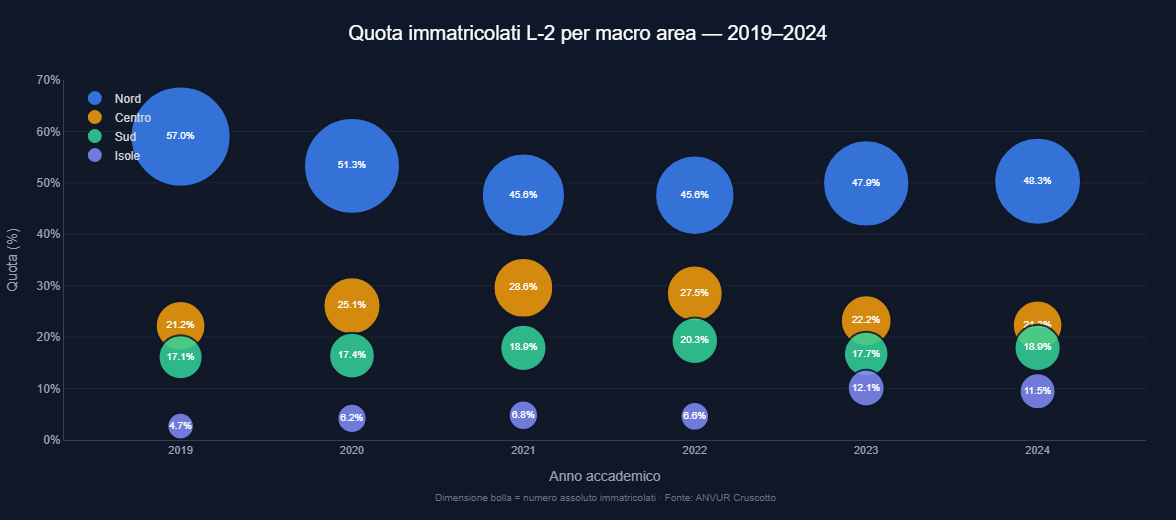

In [43]:
# Offset Y per evitare sovrapposizioni
OFFSET = {
    'Nord'  : 2,
    'Centro': 1,
    'Sud'   : -1,
    'Isole' : -2,
}

fig10 = go.Figure()

for macro in ['Nord', 'Centro', 'Sud', 'Isole']:
    subset = macro_pct[macro_pct['macro'] == macro].sort_values('Anno accademico').copy()
    subset['pct_offset'] = subset['pct'] + OFFSET[macro]

    fig10.add_trace(go.Scatter(
        x=subset['Anno accademico'].astype(str),
        y=subset['pct_offset'],
        mode='markers+text',
        name=macro,
        marker=dict(
            size=subset['imm'] / macro_pct['imm'].max() * 80 + 20,
            color=COLORI_MACRO[macro],
            opacity=0.85,
            line=dict(color='#0F172A', width=2)
        ),
        text=subset['pct'].apply(lambda x: f'{x:.1f}%'),
        textposition='middle center',
        textfont=dict(size=10, color='white', family='Arial'),
        hovertemplate=(
            f'<b>{macro}</b><br>'
            'Anno: %{x}<br>'
            'Quota: <b>%{customdata[0]:.1f}%</b><br>'
            'Immatricolati: <b>%{customdata[1]:,}</b>'
            '<extra></extra>'
        ),
        customdata=list(zip(subset['pct'], subset['imm'].astype(int))),
    ))

fig10.update_layout(
    title=dict(
        text='Quota immatricolati L-2 per macro area — 2019–2024',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Anno accademico', font=dict(color='#9CA3AF')),
        showgrid=False,
        tickfont=dict(size=11, color='#9CA3AF'),
        linecolor='#374151',
    ),
    yaxis=dict(
        title=dict(text='Quota (%)', font=dict(color='#9CA3AF')),
        gridcolor='#1F2937',
        ticksuffix='%',
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
        range=[0, 70]
    ),
    legend=dict(
        font=dict(color='#D1D5DB', size=12),
        bgcolor='rgba(0,0,0,0)',
        x=0.01, y=0.99
    ),
    annotations=[
        dict(
            x=0.5, y=-0.18,
            xref='paper', yref='paper',
            text='Dimensione bolla = numero assoluto immatricolati · Fonte: ANVUR Cruscotto',
            showarrow=False,
            font=dict(size=10, color='#6B7280'),
            align='center'
        )
    ],
    height=520,
    margin=dict(t=80, b=80, l=60, r=30),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
)

fig10.show()

In [52]:
# Confronto varianti vs Biotecnologie come baseline
baseline = ic14_var[ic14_var['corso'] == 'Biotecnologie']['prosecuzione_pct'].values[0]

# Solo varianti con prosecuzione MAGGIORE di Biotecnologie
migliori = (
    ic14_var[ic14_var['prosecuzione_pct'] > baseline]
    .sort_values('prosecuzione_pct', ascending=True)
    .reset_index(drop=True)
)

print(f'Baseline Biotecnologie: {baseline}%')
print()
print(migliori[['corso','n_atenei','prosecuzione_pct','abbandono']].to_string(index=False))

Baseline Biotecnologie: 51.5%

                                                      corso  n_atenei  prosecuzione_pct  abbandono
                                      Biotecnologie Mediche         2              57.4       42.6
                                              Biotecnologia         1              60.2       39.8
                            Scienze E Tecnologie Biologiche         2              63.6       36.4
                Biotecnologie Agro-Alimentari E Industriali         1              67.5       32.5
Bioscienze E Biotecnologia -  Biosciences And Biotechnology         1              69.1       30.9
                                             Bioinformatica         1              72.9       27.1
                         Ricerca Biotecnologica In Medicina         1              78.5       21.5
                         Scienze E Tecnologie Biomolecolari         1              81.4       18.6
                                                   Genomica         1         

In [57]:
# Confronta Biotecnologie vs Biotecnologia
for nome in ['Biotecnologie', 'Biotecnologia']:
    subset = ic14[ic14['corso_norm'] == nome]
    print(f'{nome}:')
    print(f'  Atenei: {subset["CODE_UN"].nunique()}')
    print(f'  Anni: {sorted(subset["ID_ANNO_ACCADEMICO"].unique())}')
    print(f'  Atenei codici: {sorted(subset["CODE_UN"].unique())}')
    print()

Biotecnologie:
  Atenei: 33
  Anni: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Atenei codici: ['03', '04', '08', '09', '10', '11', '12', '14', '17', '19', '20', '21', '22', '23', '24', '26', '27', '30', '31', '34', '35', '38', '40', '46', '49', '55', '63', 'A8', 'C4', 'C5', 'C6', 'C7', 'C8']

Biotecnologia:
  Atenei: 1
  Anni: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  Atenei codici: ['15']



In [58]:
# Unisci Biotecnologia → Biotecnologie
ic14['corso_norm'] = ic14['corso_norm'].str.replace(
    'Biotecnologia$', 'Biotecnologie', regex=True
)

# Ricalcola tutto
ic14_var = ic14.groupby('corso_norm')['ind_float'].mean().reset_index()
ic14_var.columns = ['corso', 'prosecuzione']
ic14_var['prosecuzione_pct'] = (ic14_var['prosecuzione'] * 100).round(1)
ic14_var['abbandono'] = (100 - ic14_var['prosecuzione_pct']).round(1)

ic14_atenei = ic14.groupby('corso_norm')['CODE_UN'].nunique().reset_index()
ic14_atenei.columns = ['corso', 'n_atenei']
ic14_var = ic14_var.merge(ic14_atenei, on='corso')

baseline = ic14_var[ic14_var['corso'] == 'Biotecnologie']['prosecuzione_pct'].values[0]

print(f'Biotecnologie ora ha {ic14_var[ic14_var["corso"]=="Biotecnologie"]["n_atenei"].values[0]} atenei')
print(f'Prosecuzione: {baseline}%')
print()
print(ic14_var[['corso','n_atenei','prosecuzione_pct','abbandono']].sort_values('prosecuzione_pct', ascending=False).to_string(index=False))

Biotecnologie ora ha 34 atenei
Prosecuzione: 51.8%

                                                       corso  n_atenei  prosecuzione_pct  abbandono
                                                    Genomica         1              85.8       14.2
                          Scienze E Tecnologie Biomolecolari         1              81.4       18.6
                          Ricerca Biotecnologica In Medicina         1              78.5       21.5
                                              Bioinformatica         1              72.9       27.1
 Bioscienze E Biotecnologia -  Biosciences And Biotechnology         1              69.1       30.9
                 Biotecnologie Agro-Alimentari E Industriali         1              67.5       32.5
                             Scienze E Tecnologie Biologiche         2              63.6       36.4
                                       Biotecnologie Mediche         2              57.4       42.6
                                               B

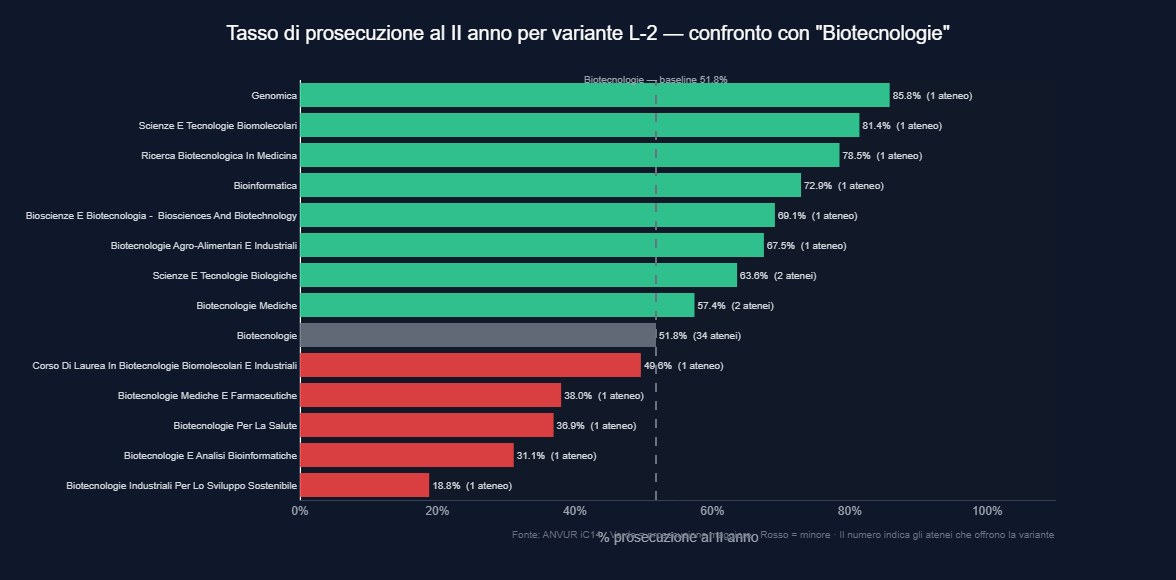

In [62]:
# Ricalcola con Biotecnologia → Biotecnologie già unito
ic14['corso_norm'] = ic14['NOME_CORSO'].str.title().str.strip()
ic14['corso_norm'] = ic14['corso_norm'].str.replace('Biotecnologia$', 'Biotecnologie', regex=True)

ic14_var = ic14.groupby('corso_norm')['ind_float'].mean().reset_index()
ic14_var.columns = ['corso', 'prosecuzione']
ic14_var['prosecuzione_pct'] = (ic14_var['prosecuzione'] * 100).round(1)
ic14_var['abbandono'] = (100 - ic14_var['prosecuzione_pct']).round(1)

ic14_atenei = ic14.groupby('corso_norm')['CODE_UN'].nunique().reset_index()
ic14_atenei.columns = ['corso', 'n_atenei']
ic14_var = ic14_var.merge(ic14_atenei, on='corso')

baseline = ic14_var[ic14_var['corso'] == 'Biotecnologie']['prosecuzione_pct'].values[0]

# Ordina per prosecuzione crescente
ic14_var_sorted = ic14_var.sort_values('prosecuzione_pct', ascending=True).reset_index(drop=True)

# Colori
def get_colore(row):
    if row['corso'] == 'Biotecnologie':
        return '#6B7280'
    elif row['prosecuzione_pct'] > baseline:
        return '#34D399'
    else:
        return '#EF4444'

ic14_var_sorted['colore'] = ic14_var_sorted.apply(get_colore, axis=1)

fig12 = go.Figure()

fig12.add_trace(go.Bar(
    x=ic14_var_sorted['prosecuzione_pct'],
    y=ic14_var_sorted['corso'],
    orientation='h',
    marker=dict(
        color=ic14_var_sorted['colore'],
        line=dict(width=0),
        opacity=0.9
    ),
    text=ic14_var_sorted.apply(
        lambda r: f"{r['prosecuzione_pct']:.1f}%  ({r['n_atenei']} aten{'eo' if r['n_atenei']==1 else 'ei'})",
        axis=1
    ),
    textposition='outside',
    textfont=dict(size=10, color='#D1D5DB'),
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Prosecuzione: <b>%{x:.1f}%</b><br>'
        'Abbandono: <b>%{customdata[0]:.1f}%</b><br>'
        'N° atenei: <b>%{customdata[1]}</b>'
        '<extra></extra>'
    ),
    customdata=list(zip(ic14_var_sorted['abbandono'], ic14_var_sorted['n_atenei'])),
))

# Linea verticale baseline
fig12.add_vline(
    x=baseline,
    line=dict(color='#6B7280', width=2, dash='dash'),
)

fig12.update_layout(
    title=dict(
        text='Tasso di prosecuzione al II anno per variante L-2 — confronto con "Biotecnologie"',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='% prosecuzione al II anno', font=dict(color='#9CA3AF')),
        showgrid=False,
        ticksuffix='%',
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
        range=[0, 110]
    ),
    yaxis=dict(
        showgrid=False,
        tickfont=dict(size=10, color='#D1D5DB'),
        linecolor='#374151',
    ),
    annotations=[
        dict(
            x=baseline, y=1.02,
            xref='x', yref='paper',
            text=f'Biotecnologie — baseline {baseline:.1f}%',
            showarrow=False,
            font=dict(size=10, color='#9CA3AF'),
            align='center'
        ),
        dict(
            x=1.0, y=-0.10,
            xref='paper', yref='paper',
            text='Fonte: ANVUR iC14 · Verde = prosecuzione maggiore · Rosso = minore · Il numero indica gli atenei che offrono la variante',
            showarrow=False,
            font=dict(size=10, color='#6B7280'),
            align='right', xanchor='right'
        )
    ],
    height=580,
    margin=dict(t=80, b=80, l=300, r=120),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
)

fig12.show()

In [64]:
# ── Correlazione dimensione corso vs tasso prosecuzione ──────────────────

# Immatricolati per corso e ateneo (media 2020-2023)
imm_corso = df_ava2[
    (df_ava2['CODICE'] == 'iC00b') &
    (df_ava2['ID_ANNO_ACCADEMICO'] >= 2020)
].copy()

imm_corso['imm'] = (
    imm_corso['NUMERATORE'].astype(str).str.strip()
    .str.replace(',', '').str.replace('.000', '')
    .apply(lambda x: float(x) if x not in ['', 'nan', 'None'] else None)
)

imm_media = (
    imm_corso.groupby(['CODICIONE'])['imm']
    .mean().reset_index()
    .rename(columns={'imm': 'imm_media'})
)

# iC14 per corso (media 2020-2023)
ic14_corso = ic14.groupby('CODICIONE')['ind_float'].mean().reset_index()
ic14_corso.columns = ['CODICIONE', 'prosecuzione']
ic14_corso['prosecuzione_pct'] = (ic14_corso['prosecuzione'] * 100).round(1)

# Merge
df_corr = imm_media.merge(ic14_corso, on='CODICIONE', how='inner')
df_corr = df_corr.merge(
    df_ava2[['CODICIONE','NOME_CORSO','CODE_UN','ID_REGIONE_MACRO_ISTAT']].drop_duplicates(),
    on='CODICIONE', how='left'
)

# Macro area da ID_REGIONE
df_corr['macro'] = df_corr['ID_REGIONE_MACRO_ISTAT'].map({
    1: 'Nord', 2: 'Nord', 3: 'Centro', 4: 'Sud e Isole'
})

# Correlazione
from scipy import stats
corr, pval = stats.pearsonr(
    df_corr['imm_media'].dropna(),
    df_corr.loc[df_corr['imm_media'].notna(), 'prosecuzione_pct']
)
print(f'Correlazione Pearson: r = {corr:.3f}, p-value = {pval:.4f}')
print(f'N osservazioni: {len(df_corr.dropna())}')
print()
print(df_corr[['NOME_CORSO','CODE_UN','imm_media','prosecuzione_pct','macro']].head(10).to_string(index=False))

Correlazione Pearson: r = -0.319, p-value = 0.0253
N osservazioni: 49

                        NOME_CORSO CODE_UN  imm_media  prosecuzione_pct macro
                     BIOTECNOLOGIE      31      159.4              60.1  Nord
                     Biotecnologie      C8      518.0              40.8  Nord
                     Biotecnologie      11      165.6              41.4  Nord
                     Biotecnologie      C7      113.8              53.2  Nord
             Biotecnologie mediche      15       95.2              58.2  Nord
                     Biotecnologia      15      203.2              60.2  Nord
Ricerca biotecnologica in medicina      A9       34.6              78.5  Nord
                     BIOTECNOLOGIE      C6      164.4              76.5  Nord
                     Biotecnologie      46       57.6              48.4  Nord
                     Biotecnologie      22      131.0              72.0  Nord


In [66]:
print('df_ava2 colonne:', df_ava2.columns.tolist())
print()
print('df_anvur colonne:', df_anvur.columns.tolist())

df_ava2 colonne: ['INTERCLASSE', 'CODE_UN', 'CODICIONE', 'NOME_CORSO', 'COD_CLASSE', 'DES_CLASSE', 'ID_COMUNE', 'COMUNE', 'ID_REGIONE_MACRO_ISTAT', 'REGIONE_MACRO_ISTAT', 'ID_CLASSE', 'DURATA', 'ID_ANNO_ACCADEMICO', 'CODICE', 'DESCRIZIONE', 'NUMERATORE', 'DENOMINATORE', 'INDICATORE', 'NUMERATORE_ITA', 'DENOMINATORE_ITA', 'INDICATORE_ITA', 'NUMERATORE_ITA_T', 'DENOMINATORE_ITA_T', 'INDICATORE_ITA_T', 'NUMERATORE_CODE_UN', 'DENOMINATORE_CODE_UN', 'INDICATORE_CODE_UN', 'NUMERATORE_MACROREGIONE', 'DENOMINATORE_MACROREGIONE', 'INDICATORE_MACROREGIONE', 'Unnamed: 30', 'ind_float']

df_anvur colonne: ['Classe', 'Nome Corso', 'Ateneo', 'Anno accademico', 'Descrizione indicatore', 'Numeratore', 'imm', 'corso_nome', 'ateneo_clean', 'ateneo_short', 'regione', 'macro']


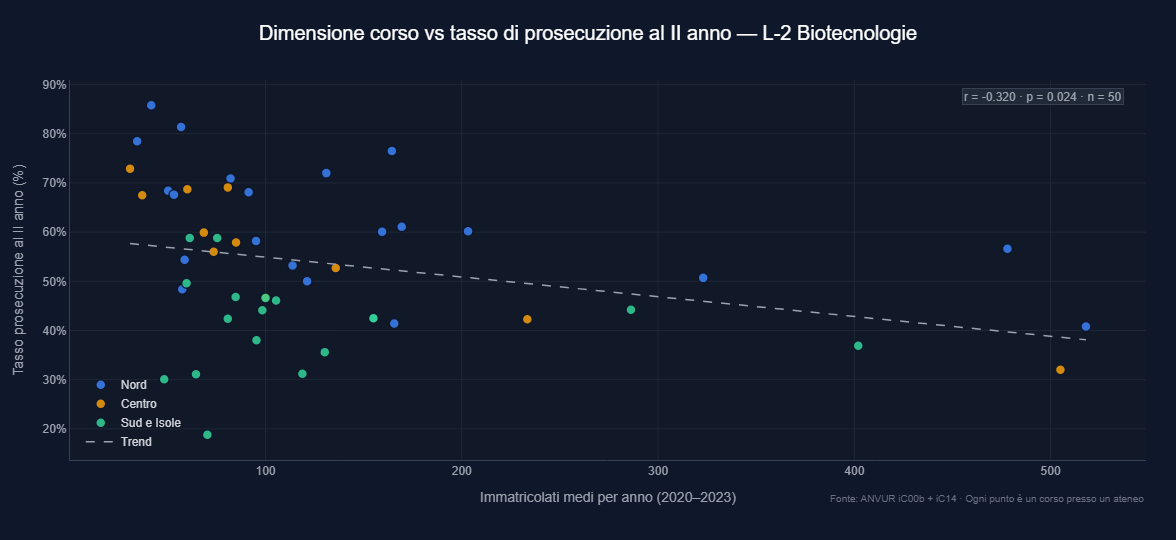

In [67]:
from scipy import stats

# ── Lookup CODE_UN → ateneo_short da PENTAHO ─────────────────────────────
# df_anvur non ha CODE_UN ma ha ateneo_short
# df_ava2 ha CODE_UN ma non ha nome ateneo
# Usiamo CODICIONE come chiave comune

codicione_ateneo = (
    df_ava2[['CODE_UN', 'CODICIONE', 'COMUNE', 'REGIONE_MACRO_ISTAT', 'ID_REGIONE_MACRO_ISTAT']]
    .drop_duplicates()
)

# Immatricolati per corso e ateneo (media 2020-2023)
imm_corso = df_ava2[
    (df_ava2['CODICE'] == 'iC00b') &
    (df_ava2['ID_ANNO_ACCADEMICO'] >= 2020)
].copy()

imm_corso['imm'] = (
    imm_corso['NUMERATORE'].astype(str).str.strip()
    .str.replace(',', '').str.replace('.000', '')
    .apply(lambda x: float(x) if x not in ['', 'nan', 'None'] else None)
)

imm_media = (
    imm_corso.groupby('CODICIONE')['imm']
    .mean().reset_index()
    .rename(columns={'imm': 'imm_media'})
)

# iC14 per corso
ic14_corso = ic14.groupby('CODICIONE')['ind_float'].mean().reset_index()
ic14_corso.columns = ['CODICIONE', 'prosecuzione']
ic14_corso['prosecuzione_pct'] = (ic14_corso['prosecuzione'] * 100).round(1)

# Merge tutto
df_corr = imm_media.merge(ic14_corso, on='CODICIONE', how='inner')
df_corr = df_corr.merge(codicione_ateneo, on='CODICIONE', how='left')
df_corr = df_corr.merge(
    df_ava2[['CODICIONE','NOME_CORSO']].drop_duplicates(),
    on='CODICIONE', how='left'
)

# Macro area
df_corr['macro'] = df_corr['ID_REGIONE_MACRO_ISTAT'].map({
    1: 'Nord', 2: 'Nord', 3: 'Centro', 4: 'Sud e Isole'
})

# Nome ateneo da COMUNE (più leggibile di CODE_UN)
df_corr['nome_display'] = df_corr['NOME_CORSO'].str.title().str.strip() + ' — ' + df_corr['COMUNE'].str.title().str.strip()

df_plot = df_corr.dropna(subset=['imm_media','prosecuzione_pct','macro']).copy()

# Correlazione
slope, intercept, r, p, se = stats.linregress(df_plot['imm_media'], df_plot['prosecuzione_pct'])
x_line = [df_plot['imm_media'].min(), df_plot['imm_media'].max()]
y_line = [slope * x + intercept for x in x_line]

COLORI_MACRO4 = {
    'Nord': '#3B82F6',
    'Centro': '#F59E0B',
    'Sud e Isole': '#34D399',
}

fig_corr = go.Figure()

for macro, colore in COLORI_MACRO4.items():
    sub = df_plot[df_plot['macro'] == macro]
    fig_corr.add_trace(go.Scatter(
        x=sub['imm_media'],
        y=sub['prosecuzione_pct'],
        mode='markers',
        name=macro,
        marker=dict(
            color=colore,
            size=10,
            opacity=0.85,
            line=dict(color='#0F172A', width=1.5)
        ),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'Immatricolati medi: <b>%{x:.0f}</b><br>'
            'Prosecuzione: <b>%{y:.1f}%</b>'
            '<extra></extra>'
        ),
        customdata=list(zip(sub['nome_display'],))
    ))

# Linea regressione
fig_corr.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    name='Trend',
    line=dict(color='#9CA3AF', width=1.5, dash='dash'),
    hoverinfo='skip'
))

fig_corr.update_layout(
    title=dict(
        text='Dimensione corso vs tasso di prosecuzione al II anno — L-2 Biotecnologie',
        font=dict(size=20, color='white', family='Arial'),
        x=0.5, xanchor='center'
    ),
    xaxis=dict(
        title=dict(text='Immatricolati medi per anno (2020–2023)', font=dict(color='#9CA3AF')),
        showgrid=True, gridcolor='#1F2937',
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
    ),
    yaxis=dict(
        title=dict(text='Tasso prosecuzione al II anno (%)', font=dict(color='#9CA3AF')),
        showgrid=True, gridcolor='#1F2937',
        ticksuffix='%',
        tickfont=dict(color='#9CA3AF'),
        linecolor='#374151',
    ),
    legend=dict(
        font=dict(color='#D1D5DB', size=12),
        bgcolor='rgba(0,0,0,0)',
        x=0.01, y=0.01
    ),
    annotations=[
        dict(
            x=0.98, y=0.98,
            xref='paper', yref='paper',
            text=f'r = {r:.3f} · p = {p:.3f} · n = {len(df_plot)}',
            showarrow=False,
            font=dict(size=12, color='#9CA3AF'),
            align='right', xanchor='right',
            bgcolor='#1F2937',
            bordercolor='#374151',
            borderwidth=1,
        ),
        dict(
            x=1.0, y=-0.12,
            xref='paper', yref='paper',
            text='Fonte: ANVUR iC00b + iC14 · Ogni punto è un corso presso un ateneo',
            showarrow=False,
            font=dict(size=10, color='#6B7280'),
            align='right', xanchor='right'
        )
    ],
    height=540,
    margin=dict(t=80, b=80, l=70, r=30),
    font=dict(family='Arial', size=12),
    plot_bgcolor='#111827',
    paper_bgcolor='#0F172A',
)

fig_corr.show()

In [68]:
# Lookup CODICIONE → ateneo_short da df_anvur
# df_anvur ha 'corso_nome' e 'ateneo_short' ma non CODICIONE
# Usiamo corso_nome + ateneo per matchare

# In df_ava2 abbiamo CODICIONE e NOME_CORSO
# In df_anvur abbiamo corso_nome e ateneo_short
# Proviamo a matchare su nome corso normalizzato

df_ava2['corso_norm_join'] = df_ava2['NOME_CORSO'].str.title().str.strip()
df_anvur['corso_norm_join'] = df_anvur['corso_nome'].str.title().str.strip()

lookup = df_anvur[['corso_norm_join','ateneo_short','ateneo_clean']].drop_duplicates()

df_corr['corso_norm_join'] = df_corr['NOME_CORSO'].str.title().str.strip()
df_corr = df_corr.merge(lookup, on='corso_norm_join', how='left')

df_corr['nome_display'] = (
    df_corr['NOME_CORSO'].str.title().str.strip() + 
    ' — ' + 
    df_corr['ateneo_short'].fillna(df_corr['COMUNE'].str.title())
)

print(df_corr[['NOME_CORSO','ateneo_short','nome_display']].head(10).to_string(index=False))

   NOME_CORSO       ateneo_short                       nome_display
BIOTECNOLOGIE             Torino             Biotecnologie — Torino
BIOTECNOLOGIE Piemonte Orientale Biotecnologie — Piemonte Orientale
BIOTECNOLOGIE             Genova             Biotecnologie — Genova
BIOTECNOLOGIE      dell'Insubria      Biotecnologie — dell'Insubria
BIOTECNOLOGIE            Bicocca            Biotecnologie — Bicocca
BIOTECNOLOGIE            Brescia            Biotecnologie — Brescia
BIOTECNOLOGIE              Pavia              Biotecnologie — Pavia
BIOTECNOLOGIE             Verona             Biotecnologie — Verona
BIOTECNOLOGIE             Padova             Biotecnologie — Padova
BIOTECNOLOGIE              Udine              Biotecnologie — Udine


In [70]:
print(f'Righe df_corr prima dropna: {len(df_corr)}')
print(f'Righe df_plot dopo dropna: {len(df_plot)}')
print()
# Controlla duplicati
print('Duplicati CODICIONE in df_corr:')
print(df_corr['CODICIONE'].duplicated().sum())

Righe df_corr prima dropna: 1142
Righe df_plot dopo dropna: 1142

Duplicati CODICIONE in df_corr:
1093


In [71]:
from scipy import stats

# ── Lookup CODICIONE → ateneo_short tramite PENTAHO ──────────────────────
# PENTAHO ha Nome Corso con codice tipo "0010106200200003 - BIOTECNOLOGIE"
# Il codice è il CODICIONE — estraiamolo

df_anvur['CODICIONE'] = df_anvur['Nome Corso'].str.split(' - ').str[0].str.strip()

lookup = df_anvur[['CODICIONE','ateneo_short']].drop_duplicates('CODICIONE')

print(f'Lookup righe: {len(lookup)}')
print(lookup.head(5).to_string(index=False))

Lookup righe: 50
       CODICIONE       ateneo_short
0010106200200003             Torino
0020106200200004 Piemonte Orientale
0100106200200004             Genova
0120206200200001      dell'Insubria
0150106200200003             Milano


In [75]:
print(f'Righe df_plot: {len(df_plot)}')
print(f'Duplicati CODICIONE: {df_plot["CODICIONE"].duplicated().sum()}')
print(f'r = {r:.3f}, p = {p:.4f}, n = {len(df_plot)}')

Righe df_plot: 49
Duplicati CODICIONE: 0
r = -0.319, p = 0.0253, n = 49
